# Phase 4 — Scorecard ASB workbench (PD Ins + PD Css)

Tune bins and prescreen, fit models, review bin stability on shortlisted variables, then build scorecard.

Work one product at a time (`PRODUCT`). Freeze bins before §3.

Each helper is **one cell** with a `checkpoint` block at the bottom. Run top-to-bottom; checkpoints use pipeline data from above cells only.

## Checklist
- [ ] §0 `SCORECARD_PARAMS` + `PRODUCT`
- [ ] §1 load + partition + slice
- [ ] §2 bin tuning loop until prescreen gate passes
- [ ] §3.1–3.3 RFE + Model_list
- [ ] §3.4–3.5 diagnose + subModel_list
- [ ] §3.5b BR review (subModel_list vars only)
- [ ] §3.6–3.8 pick winner + model_package
- [ ] §4 scorecard + calibration
- [ ] §5 Gini over time
- [ ] §6 save parquet artifacts
- [ ] Repeat for `css`

| Prof reference | Notebook |
|----------------|----------|
| Big_scorecard.xlsx | `big_scorecard` + plots |
| Gini_vars.xlsx | `gini_vars` |
| Variable_report.xlsx | `variable_report` + `plot_bin_stability` |
| Model_report.xlsx | `model_report` + `display_model_report` |



## §0 — Setup

In [1]:
import json
import pickle
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)

assert Path("../data/04_feature/abt_app.parquet").exists()
assert Path("../data/04_feature/decisions.parquet").exists()

PRODUCT = "css"

SCORECARD_PARAMS = {
    "target": "default12",
    "time_col": "period",
    "id_col": "aid",
    "train_end_period": "198512",
    "valid_start_period": "198601",
    "symbol_missing": "Missing",
    "symbol_other": "<OTHERS>",
    "woe_epsilon": 1e-4,
    "tree_random_state": 1234,
    "factor": 20 / np.log(2),
    "offset": 600 - (20 / np.log(2)) * np.log(50),
    "category_order": False,
    "candidate": {"prefixes": ["app", "act"]},
    "binning": {
        "ncategories_int": 3,
        "minimum_share_int": 0.2,
        "ncategories_nom": 3,
        "rare_threshold": 0.05,
    },
    "prescreen": {
        "iv_min": 0.02,
        "gini_min": 0.02,
        "psi_max": 0.2,
        "psi_tar_max": 0.1,
        "delta_gini_max": 0.2,
        "ar_diff_max": 0.20,
    },
    "stability": {
        "min_bin_n_period": 10,
        "min_bin_n_total": 30,
        "max_bad_rate_swing": 0.4,
        "min_periods_for_stability": 6,
        "max_plots": None,
        "min_static_br_gap": 0.02,      # 2 percentage points
        "min_period_br_gap": 0.1,      # for time-gap stability checks
        "min_periods_for_gap": 1,      # min failing periods (with sufficient n) to flag
    },
    "selection": {
        "number_vars": 12,
        "number_features": 5,
        "pvalue_max": 0.01,
        "vif_max": 4.0,
        "sort_metric": "gini_valid",
        "max_features": 12,
        "epsilon": 1e-4,
    },
}

# Flat aliases for helpers that read flat keys.
SCORECARD_PARAMS.update(SCORECARD_PARAMS["binning"])
SCORECARD_PARAMS.update(SCORECARD_PARAMS["prescreen"])
SCORECARD_PARAMS.update(SCORECARD_PARAMS["stability"])
SCORECARD_PARAMS.update(SCORECARD_PARAMS["selection"])


## §1 — Data prep (run once)

**§1 cell run order** (top → bottom):
1. `prepare_target`
2. `load_and_prepare_abt`
3. **Load ABT** → creates `df_model`, `df_accepted`
4. `partition_abt` → checkpoint uses `df_accepted`
5. `slice_product`
6. `get_candidate_features`
7. **Partition + product slices** → `df_train`, `train_product`, `valid_product`


In [2]:
# Columns excluded from binning / features
LEAKAGE_COLS = [
    "default3", "default6", "default12", "decision", "decline_reason",
    "act_cus_active",
]
ID_COLS = ["cid", "aid", "period", "product"]


In [3]:
def prepare_target(df, target="default12"):
	"""Convert target to binary"""
	out = df.copy()
	out[target] = out[target].map({".i": 0, ".d": 0, 0: 0, 1: 1})
	out = out.dropna(subset=[target])
	out[target] = out[target].astype(int)
	return out

# --- checkpoint: prepare_target ---
_raw = pd.DataFrame({"default12": [".i", ".d", 0, 1, None]})
_out = prepare_target(_raw, target="default12")
print("checkpoint prepare_target:", _out["default12"].dropna().tolist())


checkpoint prepare_target: [0, 0, 0, 1]


In [4]:
def load_and_prepare_abt(abt_path, decisions_path):
	"""Load and prepare application data"""
	abt = pd.read_parquet(abt_path)
	decisions = pd.read_parquet(decisions_path)
	merged = abt.merge(
		decisions[["aid", "decision", "decline_reason"]],
		on="aid",
		how="left",
	)
	return prepare_target(merged)

# --- checkpoint: load_and_prepare_abt ---
df_model = load_and_prepare_abt(
    "../data/04_feature/abt_app.parquet",
    "../data/04_feature/decisions.parquet",
)
print(f"checkpoint load_and_prepare_abt: rows={len(df_model)} bad_rate={df_model['default12'].mean():.2%}")


checkpoint load_and_prepare_abt: rows=44602 bad_rate=41.04%


In [5]:
# §1 — Load ABT (run before partition/slice checkpoints)
df_model = load_and_prepare_abt(
    "../data/04_feature/abt_app.parquet",
    "../data/04_feature/decisions.parquet",
)
assert df_model["aid"].is_unique
print("rows:", len(df_model), "bad rate:", f"{df_model['default12'].mean():.2%}")
df_accepted = df_model[df_model["decision"] == "A"].copy()
print("accepted:", len(df_accepted))


rows: 44602 bad rate: 41.04%
accepted: 44602


In [6]:
def partition_abt(df, train_end, valid_start, time_col="period"):
	"""Filter data into train and valid sets based on period"""
	work = df.copy()
	df_train = work[work[time_col] <= train_end]
	df_valid = work[work[time_col] >= valid_start]
	return df_train, df_valid

# --- checkpoint: partition_abt ---
_acc = df_accepted
_tr, _va = partition_abt(
    _acc,
    SCORECARD_PARAMS["train_end_period"],
    SCORECARD_PARAMS["valid_start_period"],
    time_col=SCORECARD_PARAMS["time_col"],
)
print(f"checkpoint partition_abt: train={len(_tr)} valid={len(_va)}")
print(_tr[SCORECARD_PARAMS["time_col"]].min(), "→", _tr[SCORECARD_PARAMS["time_col"]].max())


checkpoint partition_abt: train=37775 valid=6827
197501 → 198512


In [7]:
def slice_product(df, product, decision="A"):
	"""Slice datasets based on product and decision"""
	return df[(df["product"] == product) & (df["decision"] == decision)].copy()

# --- checkpoint: slice_product ---
_base = _tr
_sl = slice_product(_base, PRODUCT)
print(f"checkpoint slice_product: n={len(_sl)} bad_rate={_sl['default12'].mean():.2%}")
display(_sl.head())


checkpoint slice_product: n=18932 bad_rate=69.49%


,cid,aid,product,period,act_age,act_cc,act_loaninc,app_income,app_loan_amount,app_n_installments,app_number_of_children,app_spendings,app_installment,app_char_branch,app_char_gender,app_char_job_code,app_char_marital_status,app_char_city,app_char_home_status,app_char_cars,act_call_cc,act_cins_n_loan,act_ccss_n_loan,act_call_n_loan,ags3_Mean_CMaxI_Days,agr3_Mean_CMaxI_Days,ags3_Max_CMaxI_Days,agr3_Max_CMaxI_Days,ags3_Min_CMaxI_Days,agr3_Min_CMaxI_Days,ags6_Mean_CMaxI_Days,agr6_Mean_CMaxI_Days,ags6_Max_CMaxI_Days,agr6_Max_CMaxI_Days,ags6_Min_CMaxI_Days,agr6_Min_CMaxI_Days,ags9_Mean_CMaxI_Days,agr9_Mean_CMaxI_Days,ags9_Max_CMaxI_Days,agr9_Max_CMaxI_Days,ags9_Min_CMaxI_Days,agr9_Min_CMaxI_Days,ags12_Mean_CMaxI_Days,agr12_Mean_CMaxI_Days,ags12_Max_CMaxI_Days,agr12_Max_CMaxI_Days,ags12_Min_CMaxI_Days,agr12_Min_CMaxI_Days,ags3_Mean_CMaxI_Due,agr3_Mean_CMaxI_Due,ags3_Max_CMaxI_Due,agr3_Max_CMaxI_Due,ags3_Min_CMaxI_Due,agr3_Min_CMaxI_Due,ags6_Mean_CMaxI_Due,agr6_Mean_CMaxI_Due,ags6_Max_CMaxI_Due,agr6_Max_CMaxI_Due,ags6_Min_CMaxI_Due,agr6_Min_CMaxI_Due,ags9_Mean_CMaxI_Due,agr9_Mean_CMaxI_Due,ags9_Max_CMaxI_Due,agr9_Max_CMaxI_Due,ags9_Min_CMaxI_Due,agr9_Min_CMaxI_Due,ags12_Mean_CMaxI_Due,agr12_Mean_CMaxI_Due,ags12_Max_CMaxI_Due,agr12_Max_CMaxI_Due,ags12_Min_CMaxI_Due,agr12_Min_CMaxI_Due,ags3_Mean_CMaxC_Days,agr3_Mean_CMaxC_Days,ags3_Max_CMaxC_Days,agr3_Max_CMaxC_Days,ags3_Min_CMaxC_Days,agr3_Min_CMaxC_Days,ags6_Mean_CMaxC_Days,agr6_Mean_CMaxC_Days,ags6_Max_CMaxC_Days,agr6_Max_CMaxC_Days,ags6_Min_CMaxC_Days,agr6_Min_CMaxC_Days,ags9_Mean_CMaxC_Days,agr9_Mean_CMaxC_Days,ags9_Max_CMaxC_Days,agr9_Max_CMaxC_Days,ags9_Min_CMaxC_Days,agr9_Min_CMaxC_Days,ags12_Mean_CMaxC_Days,agr12_Mean_CMaxC_Days,ags12_Max_CMaxC_Days,agr12_Max_CMaxC_Days,ags12_Min_CMaxC_Days,agr12_Min_CMaxC_Days,ags3_Mean_CMaxC_Due,agr3_Mean_CMaxC_Due,ags3_Max_CMaxC_Due,agr3_Max_CMaxC_Due,ags3_Min_CMaxC_Due,agr3_Min_CMaxC_Due,ags6_Mean_CMaxC_Due,agr6_Mean_CMaxC_Due,ags6_Max_CMaxC_Due,agr6_Max_CMaxC_Due,ags6_Min_CMaxC_Due,agr6_Min_CMaxC_Due,ags9_Mean_CMaxC_Due,agr9_Mean_CMaxC_Due,ags9_Max_CMaxC_Due,agr9_Max_CMaxC_Due,ags9_Min_CMaxC_Due,agr9_Min_CMaxC_Due,ags12_Mean_CMaxC_Due,agr12_Mean_CMaxC_Due,ags12_Max_CMaxC_Due,agr12_Max_CMaxC_Due,ags12_Min_CMaxC_Due,agr12_Min_CMaxC_Due,ags3_Mean_CMaxA_Days,agr3_Mean_CMaxA_Days,ags3_Max_CMaxA_Days,agr3_Max_CMaxA_Days,ags3_Min_CMaxA_Days,agr3_Min_CMaxA_Days,ags6_Mean_CMaxA_Days,agr6_Mean_CMaxA_Days,ags6_Max_CMaxA_Days,agr6_Max_CMaxA_Days,ags6_Min_CMaxA_Days,agr6_Min_CMaxA_Days,ags9_Mean_CMaxA_Days,agr9_Mean_CMaxA_Days,ags9_Max_CMaxA_Days,agr9_Max_CMaxA_Days,ags9_Min_CMaxA_Days,agr9_Min_CMaxA_Days,ags12_Mean_CMaxA_Days,agr12_Mean_CMaxA_Days,ags12_Max_CMaxA_Days,agr12_Max_CMaxA_Days,ags12_Min_CMaxA_Days,agr12_Min_CMaxA_Days,ags3_Mean_CMaxA_Due,agr3_Mean_CMaxA_Due,ags3_Max_CMaxA_Due,agr3_Max_CMaxA_Due,ags3_Min_CMaxA_Due,agr3_Min_CMaxA_Due,ags6_Mean_CMaxA_Due,agr6_Mean_CMaxA_Due,ags6_Max_CMaxA_Due,agr6_Max_CMaxA_Due,ags6_Min_CMaxA_Due,agr6_Min_CMaxA_Due,ags9_Mean_CMaxA_Due,agr9_Mean_CMaxA_Due,ags9_Max_CMaxA_Due,agr9_Max_CMaxA_Due,ags9_Min_CMaxA_Due,agr9_Min_CMaxA_Due,ags12_Mean_CMaxA_Due,agr12_Mean_CMaxA_Due,ags12_Max_CMaxA_Due,agr12_Max_CMaxA_Due,ags12_Min_CMaxA_Due,agr12_Min_CMaxA_Due,act3_n_arrears,act3_n_arrears_days,act3_n_good_days,act6_n_arrears,act6_n_arrears_days,act6_n_good_days,act9_n_arrears,act9_n_arrears_days,act9_n_good_days,act12_n_arrears,act12_n_arrears_days,act12_n_good_days,act_cins_n_loans_act,act_cins_maxdue,act_cins_min_pninst,act_cins_min_lninst,act_cins_utl,act_cins_dueutl,act_cins_cc,act_cins_seniority,act_cins_min_seniority,act_cins_n_loans_hist,act_cins_n_statC,act_cins_n_statB,act_ccss_n_loans_act,act_ccss_maxdue,act_ccss_min_pninst,act_ccss_min_lninst,act_ccss_utl,act_ccss_dueutl,act_ccss_cc,act_ccss_seniority,act_ccss_min_seniority,act_ccss_n_loans_hist,act_ccss_n_statC,act_ccss_n_statB,act_cus_active,default3,default6,default12,decision,decline_reason
0,0000000625,css1975010100063,css,197501,55.0,0.629712,1.583782,3

In [8]:
def get_candidate_features(df, product, params):
	"""Get candidate features, drop leakage columns and ID columns. Return numeric and nominal features."""
	work = slice_product(df, product)
	work = work.dropna(subset=["decision", "decline_reason"])
	prefixes = params.get("candidate", {}).get("prefixes", [])
	if prefixes:
		work = work[[c for c in work.columns if c[:3].lower() in prefixes or c in ID_COLS + LEAKAGE_COLS]]
	drop_cols = [c for c in LEAKAGE_COLS + ID_COLS if c in work.columns]
	work = work.drop(columns=drop_cols)
	numeric = [
		c for c in work.columns
		if pd.api.types.is_numeric_dtype(work[c]) and not pd.api.types.is_bool_dtype(work[c])
	]
	nominal = [
		c for c in work.columns
		if c not in numeric
		and (
			pd.api.types.is_object_dtype(work[c])
			or pd.api.types.is_string_dtype(work[c])
			or isinstance(work[c].dtype, pd.CategoricalDtype)
			or pd.api.types.is_bool_dtype(work[c])
		)
	]
	return {"numeric": numeric, "nominal": nominal, "all": numeric + nominal}

# --- checkpoint: get_candidate_features ---
cand = get_candidate_features(df_model, PRODUCT, SCORECARD_PARAMS)
print(f"checkpoint get_candidate_features: numeric={len(cand['numeric'])} nominal={len(cand['nominal'])} all={len(cand['all'])}")
print("all features:", cand["all"][:5])
print("numeric features:", cand["numeric"][:5])
print("nominal features:", cand["nominal"][:5])


checkpoint get_candidate_features: numeric=49 nominal=7 all=56
all features: ['act_age', 'act_cc', 'act_loaninc', 'app_income', 'app_loan_amount']
numeric features: ['act_age', 'act_cc', 'act_loaninc', 'app_income', 'app_loan_amount']
nominal features: ['app_char_branch', 'app_char_gender', 'app_char_job_code', 'app_char_marital_status', 'app_char_city']


In [9]:
# §1 — Partition + product slices (after all §1 helpers defined)
print(df_model.groupby(["product", "decision"])["default12"].mean())
print(f"{PRODUCT} candidates:", len(cand["all"]))
print("candidate prefixes:", SCORECARD_PARAMS["candidate"]["prefixes"])

blocked_prefixes = ("agr", "ags")
blocked_found = [f for f in cand["all"] if f.startswith(blocked_prefixes)]
print("agr/ags present:", len(blocked_found))
print("act9_n_arrears in candidates:", "act9_n_arrears" in cand["all"])

df_train, df_valid = partition_abt(
    df_accepted,
    SCORECARD_PARAMS["train_end_period"],
    SCORECARD_PARAMS["valid_start_period"],
    time_col=SCORECARD_PARAMS["time_col"],
)
train_product = slice_product(df_train, PRODUCT)
valid_product = slice_product(df_valid, PRODUCT)

for name, d in [("train", train_product), ("valid", valid_product)]:
    print(
        name,
        d["period"].min(), "→", d["period"].max(),
        "bad_rate", f"{d['default12'].mean():.2%}",
        "n", len(d),
    )


product  decision
css      A           0.683755
ins      A           0.137648
Name: default12, dtype: float64
css candidates: 56
candidate prefixes: ['app', 'act']
agr/ags present: 0
act9_n_arrears in candidates: True
train 197501 → 198512 bad_rate 69.49% n 18932
valid 198601 → 198712 bad_rate 62.09% n 3345


## §2 — Bin tuning loop (linear manual review)

1. **§2a–§2d** — helpers (run once)
2. **§2e** — plot helpers (run once; required before §2.2)
3. **§2.1** Overview — auto-fit bins/WOE; creates review artifacts
4. **§2.2a** Pick `feature_to_review` from `manual_review_batch`
5. **§2.2b** Detail review — plots + tables for one variable
6. **§2.3a** Edit `manual_bin_edits` (cutpoints / groups) → auto-compiles to `manual_binning_overrides`
7. **§2.3b** Apply overrides + refresh artifacts
8. **§2.3b-post** Re-inspect overridden feature(s) (same feature, updated bins)
9. **§2.3c** Edit `manual_variable_decisions` dict
10. **§2.3d** Apply decisions + rebuild queue
11. Repeat **§2.2a → §2.3d** until acceptable (do **not** rerun §2.1)
12. **§2.4** Final gate before §3

**Naming:** `_cp_*` variables are checkpoint smoke tests on 3 features only. §2.2 stability plots require pipeline variables from **§2.1** (`train_binned`, not `_cp_train_binned`).

Re-run **§2.1** only when you want a fresh auto-fit for all candidates (e.g. new product / new cycle).


### §2a — Binning helpers

In [10]:
def _bin_params(params):
		"""Get bin parameters"""
		return {
				"other_label": params.get("symbol_other", "<OTHERS>"),
				"missing_label": params.get("symbol_missing", "Missing"),
				"max_bins": params.get("ncategories_int", 4),
				"min_bin_size": params.get("minimum_share_int", 0.03),
				"tree_random_state": params.get("tree_random_state", 1234),
				"rare_threshold": params.get("rare_threshold", params.get("minimum_share_unique", 0.03)),
				"max_groups": params.get("ncategories_nom", 4),
				"nominal_int_threshold": params.get("nominal_int_threshold", 10),
		}

# --- checkpoint: _bin_params ---
_bp = _bin_params(SCORECARD_PARAMS)
print("checkpoint _bin_params:", _bp)


checkpoint _bin_params: {'other_label': '<OTHERS>', 'missing_label': 'Missing', 'max_bins': 3, 'min_bin_size': 0.2, 'tree_random_state': 1234, 'rare_threshold': 0.05, 'max_groups': 3, 'nominal_int_threshold': 10}


In [11]:
def _numeric_interval_labels(feature, edges, missing_label):
	"""Get numeric interval labels (numeric edges only; missing is separate)."""
	intervals = []
	for i in range(len(edges) - 1):
		left, right = edges[i], edges[i + 1]
		if left == -np.inf and right == np.inf:
			intervals.append(f"{feature} (all)")
		elif left == -np.inf:
			intervals.append(f"{feature} < {right}")
		elif right == np.inf:
			intervals.append(f"{left} <= {feature}")
		else:
			intervals.append(f"{left} <= {feature} < {right}")
	return intervals

# --- checkpoint: _numeric_interval_labels ---
_edges = [-np.inf, 30.0, 55.0, np.inf]
_lbls = _numeric_interval_labels("act_age", _edges, SCORECARD_PARAMS["symbol_missing"])
print("checkpoint _numeric_interval_labels:", _lbls)
_edges0 = [-np.inf, np.inf]
print("checkpoint _numeric_interval_labels (no split):", _numeric_interval_labels("act_cins_utl", _edges0, SCORECARD_PARAMS["symbol_missing"]))


checkpoint _numeric_interval_labels: ['act_age < 30.0', '30.0 <= act_age < 55.0', '55.0 <= act_age']
checkpoint _numeric_interval_labels (no split): ['act_cins_utl (all)']


In [12]:
def _assign_numeric_bin(x, edges, intervals, missing_label, missing_bin):
	"""Assign numeric bin to a value"""
	if pd.isna(x):
		return missing_label if missing_bin else intervals[0]
	for i in range(len(edges) - 1):
		left, right = edges[i], edges[i + 1]
		if left == -np.inf and right == np.inf:
			return intervals[i]
		if left == -np.inf and x < right:
			return intervals[i]
		if right == np.inf and x >= left:
			return intervals[i]
		if left <= x < right:
			return intervals[i]
	return intervals[-1]

# --- checkpoint: _assign_numeric_bin ---
_edges = [-np.inf, 30.0, 55.0, np.inf]
_lbls = _numeric_interval_labels("act_age", _edges, SCORECARD_PARAMS["symbol_missing"])
for _x in [20, 40, 70, np.nan]:
    print(f"  x={_x!r} → {_assign_numeric_bin(_x, _edges, _lbls, SCORECARD_PARAMS['symbol_missing'], True)!r}")
_edges0 = [-np.inf, np.inf]
_lbls0 = _numeric_interval_labels("act_cins_utl", _edges0, SCORECARD_PARAMS["symbol_missing"])
print(f"  x=0.5 (no split) → {_assign_numeric_bin(0.5, _edges0, _lbls0, SCORECARD_PARAMS['symbol_missing'], True)!r}")
print("checkpoint _assign_numeric_bin: ok")


  x=20 → 'act_age < 30.0'
  x=40 → '30.0 <= act_age < 55.0'
  x=70 → '55.0 <= act_age'
  x=nan → 'Missing'
  x=0.5 (no split) → 'act_cins_utl (all)'
checkpoint _assign_numeric_bin: ok


In [13]:
def fit_bin_numeric(train, feature, target, params):
	"""Fit numeric bins"""
	cfg = _bin_params(params)
	miss_rate = train[feature].isna().mean()
	miss_share = 1 - miss_rate
	if miss_share <= 1e-5:
		miss_share = 1.0

	minimum_share = params["minimum_share_int"] / miss_share
	if minimum_share > 0.5:
		minimum_share = 0.5
	if minimum_share < params["minimum_share_int"]:
		minimum_share = params["minimum_share_int"]

	df_two = train[[target, feature]].dropna(subset=[feature])

	tree = DecisionTreeClassifier(
		max_leaf_nodes=cfg["max_bins"],
		min_weight_fraction_leaf=minimum_share,
		random_state=cfg["tree_random_state"],
	)
	tree.fit(df_two[feature].values.reshape(-1, 1), df_two[target])

	thresh = [round(s, 3) for s in tree.tree_.threshold if s != -2]
	edges = sorted([-np.inf, np.inf] + thresh)

	missing_bin = miss_rate > params["minimum_share_int"]
	intervals = _numeric_interval_labels(feature, edges, cfg["missing_label"])
	no_numeric_split = len(thresh) == 0

	return {
		"type": "numeric",
		"feature": feature,
		"edges": edges,
		"intervals": intervals,
		"missing_label": cfg["missing_label"],
		"missing_bin": missing_bin,
		"no_numeric_split": no_numeric_split,
	}

# --- checkpoint: fit_bin_numeric ---
_cp_data = train_product
_cp_feat_num = cand["numeric"][0]
_cp_num_spec = fit_bin_numeric(_cp_data, _cp_feat_num, SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
print(f"checkpoint fit_bin_numeric ({_cp_feat_num}): type={_cp_num_spec['type']} edges={len(_cp_num_spec['edges'])}")


checkpoint fit_bin_numeric (act_age): type=numeric edges=4


In [14]:
def fit_bin_nominal(train, feature, target, params):
	"""Fit nominal bins"""
	cfg = _bin_params(params)
	other_label = cfg["other_label"]
	missing_label = cfg["missing_label"]
	rare_threshold = cfg["rare_threshold"]
	max_groups = cfg["max_groups"]

	share = train.groupby(feature)[target].count() / train.shape[0]
	rate = train.groupby(feature)[target].mean()
	df_two = rate.to_frame(target).assign(share=share)
	df_two = df_two.loc[df_two["share"] > rare_threshold]

	n_clusters = min(max_groups, len(df_two))
	if n_clusters >= 2:
		labels = AgglomerativeClustering(
			n_clusters=n_clusters, metric="euclidean", linkage="ward"
		).fit_predict(df_two[[target]])
		df_two["cluster"] = labels
	else:
		df_two["cluster"] = 0

	labsc = df_two[["cluster"]].copy()
	if df_two["share"].sum() < (1 - rare_threshold):
		labsc.loc[other_label] = -1
		labsc["cluster"] = labsc["cluster"] + 1
	labsc = labsc.sort_values("cluster").reset_index()

	intervals = []
	cluster_to_label = {}
	current_cluster = None
	current_text = ""
	for _, row in labsc.iterrows():
		cat = str(row[feature])
		cl = int(row["cluster"])
		if current_cluster is None:
			current_text, current_cluster = cat, cl
		elif cl == current_cluster:
			current_text += f", {cat}"
		else:
			intervals.append(current_text)
			cluster_to_label[current_cluster] = current_text
			current_text, current_cluster = cat, cl
	if current_text:
		intervals.append(current_text)
		cluster_to_label[current_cluster] = current_text

	category_map = {
		str(row[feature]): cluster_to_label[int(row["cluster"])]
		for _, row in labsc.iterrows()
		if row[feature] != other_label
	}
	for cat in train[feature].dropna().astype(str).unique():
		if cat not in category_map:
			category_map[cat] = other_label

	return {
		"type": "nominal",
		"feature": feature,
		"category_map": category_map,
		"intervals": intervals,
		"other_label": other_label,
		"missing_label": missing_label,
	}

# --- checkpoint: fit_bin_nominal ---
_cp_data = train_product
_cp_feat_nom = cand["nominal"][0]
_cp_nom_spec = fit_bin_nominal(_cp_data, _cp_feat_nom, SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
print(f"checkpoint fit_bin_nominal ({_cp_feat_nom}): clusters={len(_cp_nom_spec['intervals'])}")


checkpoint fit_bin_nominal (app_char_branch): clusters=1


In [15]:
def fit_binning_maps(train, features, target, params):
	"""Fit binning maps"""
	cfg = _bin_params(params)
	nominal_int_threshold = cfg["nominal_int_threshold"]
	binning_maps = {}
	for feat in features:
		col = train[feat]
		is_nominal = (
			pd.api.types.is_bool_dtype(col)
			or pd.api.types.is_object_dtype(col)
			or pd.api.types.is_string_dtype(col)
			or isinstance(col.dtype, pd.CategoricalDtype)
			or (
					pd.api.types.is_integer_dtype(col)
					and col.nunique(dropna=True) <= nominal_int_threshold
			)
		)
		if is_nominal:
			binning_maps[feat] = fit_bin_nominal(train, feat, target, params)
		else:
			binning_maps[feat] = fit_bin_numeric(train, feat, target, params)
	return binning_maps

# --- checkpoint: fit_binning_maps ---
_cp_data = train_product
_cp_feats = cand["all"][:3]
_cp_maps = fit_binning_maps(_cp_data, _cp_feats, SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
print(f"checkpoint fit_binning_maps: {len(_cp_maps)} features → {list(_cp_maps.keys())}")
_cp_maps


checkpoint fit_binning_maps: 3 features → ['act_age', 'act_cc', 'act_loaninc']


{'act_age': {'type': 'numeric',
  'feature': 'act_age',
  'edges': [-inf, np.float64(61.5), np.float64(69.5), inf],
  'intervals': ['act_age < 61.5', '61.5 <= act_age < 69.5', '69.5 <= act_age'],
  'missing_label': 'Missing',
  'missing_bin': np.False_,
  'no_numeric_split': False},
 'act_cc': {'type': 'numeric',
  'feature': 'act_cc',
  'edges': [-inf, np.float64(0.506), np.float64(0.636), inf],
  'intervals': ['act_cc < 0.506',
   '0.506 <= act_cc < 0.636',
   '0.636 <= act_cc'],
  'missing_label': 'Missing',
  'missing_bin': np.False_,
  'no_numeric_split': False},
 'act_loaninc': {'type': 'numeric',
  'feature': 'act_loaninc',
  'edges': [-inf, np.float64(2.325), np.float64(5.817), inf],
  'intervals': ['act_loaninc < 2.325',
   '2.325 <= act_loaninc < 5.817',
   '5.817 <= act_loaninc'],
  'missing_label': 'Missing',
  'missing_bin': np.False_,
  'no_numeric_split': False}}

In [16]:
def extract_bin_edit(spec):
	"""Minimal editable view from a full binning spec."""
	spec_type = spec["type"]
	if spec_type == "numeric":
		cutpoints = [float(e) for e in spec["edges"] if np.isfinite(e)]
		return {"type": "numeric", "cutpoints": cutpoints}
	if spec_type == "nominal":
		other_label = spec.get("other_label")
		missing_label = spec.get("missing_label")
		label_to_cats = {}
		for cat, label in spec.get("category_map", {}).items():
			if label in (other_label, missing_label):
				continue
			label_to_cats.setdefault(label, []).append(str(cat))
		groups = [label_to_cats[label] for label in spec.get("intervals", []) if label in label_to_cats]
		return {"type": "nominal", "groups": groups}
	raise ValueError(f"Unknown binning type: {spec_type}")


def compile_bin_spec(feature, edit, base_spec):
	"""Build full binning spec from minimal edit + base metadata."""
	edit_type = edit["type"]
	if edit_type == "numeric":
		cutpoints = sorted(float(x) for x in edit["cutpoints"])
		edges = [-np.inf] + cutpoints + [np.inf]
		missing_label = base_spec["missing_label"]
		intervals = _numeric_interval_labels(feature, edges, missing_label)
		return {
			"type": "numeric",
			"feature": feature,
			"edges": edges,
			"intervals": intervals,
			"missing_label": missing_label,
			"missing_bin": bool(base_spec.get("missing_bin", False)),
			"no_numeric_split": len(cutpoints) == 0,
		}
	if edit_type == "nominal":
		groups = [[str(c) for c in g] for g in edit["groups"]]
		intervals = [", ".join(cats) for cats in groups]
		category_map = {cat: label for label, cats in zip(intervals, groups) for cat in cats}
		other_label = base_spec["other_label"]
		missing_label = base_spec["missing_label"]
		for cat in base_spec.get("category_map", {}):
			scat = str(cat)
			if scat not in category_map:
				category_map[scat] = other_label
		return {
			"type": "nominal",
			"feature": feature,
			"category_map": category_map,
			"intervals": intervals,
			"other_label": other_label,
			"missing_label": missing_label,
		}
	raise ValueError(f"Unknown edit type: {edit_type}")


def build_manual_binning_overrides(manual_bin_edits, binning_maps, params=None):
	return {
		feat: compile_bin_spec(feat, edit, binning_maps[feat])
		for feat, edit in manual_bin_edits.items()
	}


def display_bin_edit_sheet(feature, edit):
	"""Human-readable summary of what to edit in manual_bin_edits."""
	if edit["type"] == "numeric":
		n_bins = len(edit["cutpoints"]) + 1
		print(f"'{feature}': {{'type': 'numeric', 'cutpoints': {edit['cutpoints']}}}  → {n_bins} bin(s)")
	elif edit["type"] == "nominal":
		print(f"'{feature}': {{'type': 'nominal', 'groups': {edit['groups']}}}  → {len(edit['groups'])} group(s):")
		for i, g in enumerate(edit["groups"], 1):
			print(f"  bin {i}: {g}")
	else:
		print(f"{feature}  unknown edit type: {edit.get('type')}")

# "act_ccss_dueutl": {"type": "numeric", "cutpoints": [0.009, 0.057]},
	# "act3_n_arrears": {"type": "nominal", "groups": [["0", "1"], ["3"], ["2"]]},
# --- checkpoint: bin_edit_layer ---
_cp_edit_num = extract_bin_edit(_cp_maps["act_age"])
_cp_compiled = compile_bin_spec("act_age", _cp_edit_num, _cp_maps["act_age"])
assert _cp_compiled["intervals"] == _cp_maps["act_age"]["intervals"]
print("checkpoint bin_edit_layer: ok")
display_bin_edit_sheet("act_age", _cp_edit_num)

checkpoint bin_edit_layer: ok
'act_age': {'type': 'numeric', 'cutpoints': [61.5, 69.5]}  → 3 bin(s)


In [17]:
def apply_bins(df, binning_maps):
	"""Apply bins to a dataset"""
	base = df.drop(columns=[c for c in df.columns if c.endswith("_GRP")], errors="ignore")
	new_cols = {}
	for feat, spec in binning_maps.items():
			grp_col = f"{feat}_GRP"
			if spec["type"] == "numeric":
					new_cols[grp_col] = base[feat].apply(
							lambda x: _assign_numeric_bin(
									x,
									spec["edges"],
									spec["intervals"],
									spec["missing_label"],
									spec["missing_bin"],
							)
					)
			elif spec["type"] == "nominal":
					cat_map = spec["category_map"]
					other_label = spec["other_label"]
					missing_label = spec["missing_label"]
					s = base[feat]
					missing_mask = s.isna()
					norm = s.astype("string")
					mapped = norm.map(cat_map).fillna(other_label)
					mapped.loc[missing_mask] = missing_label
					new_cols[grp_col] = mapped.astype("string")
			else:
					raise ValueError(f"Unknown binning type for {feat}: {spec['type']}")
	grp_df = pd.DataFrame(new_cols, index=base.index)
	return pd.concat([base, grp_df], axis=1).copy()

# --- checkpoint: apply_bins ---
_cp_binned = apply_bins(_cp_data.head(200), _cp_maps)
_cp_grp_cols = [c for c in _cp_binned.columns if c.endswith("_GRP")]
print(f"checkpoint apply_bins: cols added {_cp_grp_cols}")
display(_cp_binned[_cp_grp_cols].head(3))


checkpoint apply_bins: cols added ['act_age_GRP', 'act_cc_GRP', 'act_loaninc_GRP']


,act_age_GRP,act_cc_GRP,act_loaninc_GRP
0,act_age < 61.5,0.506 <= act_cc < 0.636,act_loaninc < 2.325
1,act_age < 61.5,act_cc < 0.506,act_loaninc < 2.325
2,act_age < 61.5,0.506 <= act_cc < 0.636,2.325 <= act_loaninc < 5.817


### §2b — Screening helpers

In [18]:
def compute_gini(y_true, y_score):
	"""Compute Gini coefficient, a measure of goodness of fit. The higher the better."""
	auc = roc_auc_score(y_true, y_score)
	auc = max(auc, 1 - auc)
	return float(np.clip(2 * auc - 1, 0.0, 1.0))

# --- checkpoint: compute_gini ---
_g = compute_gini([0, 0, 1, 1], [0.1, 0.2, 0.7, 0.9])
print(f"checkpoint compute_gini: {_g:.3f} (expect >0)")


checkpoint compute_gini: 1.000 (expect >0)


In [19]:
def compute_psi(train_series, valid_series, epsilon):
	"""Compute Population Stability Index (PSI), a measure of goodness of fit. The lower the better."""
	train_dist = train_series.value_counts(normalize=True)
	valid_dist = valid_series.value_counts(normalize=True)
	all_bins = train_dist.index.union(valid_dist.index)
	train_pct = train_dist.reindex(all_bins, fill_value=0) + epsilon
	valid_pct = valid_dist.reindex(all_bins, fill_value=0) + epsilon
	psi_components = (train_pct - valid_pct) * np.log(train_pct / valid_pct)
	return float(max(psi_components.sum(), 0.0))

# --- checkpoint: compute_psi ---
_psi = compute_psi(
    pd.Series(["A", "A", "B", "B", "B"]),
    pd.Series(["A", "B", "B", "C", "C"]),
    SCORECARD_PARAMS["woe_epsilon"],
)
print(f"checkpoint compute_psi: {_psi:.4f}")


checkpoint compute_psi: 3.5374


In [20]:
def check_vif(x):
	"""Check VIF (Variance Inflation Factor)"""
	x_num = x.select_dtypes(include=[np.number]).copy()
	x_ = x_num.copy()
	x_.insert(0, "_intercept", 1.0)
	vif_values = {}
	for i, col in enumerate(x_.columns):
		if col == "_intercept":
			continue
		vif_values[col] = variance_inflation_factor(x_.values, i)
	return pd.Series(vif_values, name="vif")

# --- checkpoint: check_vif ---
_rng = np.random.default_rng(0)
_x = pd.DataFrame({"f1": _rng.normal(size=50), "f2": _rng.normal(size=50)})
_vif = check_vif(_x)
print("checkpoint check_vif:")
display(_vif)


checkpoint check_vif:


f1    1.011762
f2    1.011762
Name: vif, dtype: float64

In [21]:
def prescreen_features(train_woe, valid_woe, iv_table, params):
	"""
	Prescreen features based on IV (Information Value).
	IV is a measure of the predictive power of a feature.
	Higher IV means more predictive power.
	"""
	target = params["target"]
	rows = []
	for _, row in iv_table.iterrows():
		feature = row["feature"]
		iv = row["iv"]
		woe_col = f"{feature}_WOE"
		grp_col = f"{feature}_GRP"
		reasons = []
		if iv < params["iv_min"]:
			reasons.append(f"IV < {params['iv_min']}")
		gini_train = gini_valid = ar_diff = np.nan
		if woe_col in train_woe.columns:
			gini_train = compute_gini(train_woe[target], train_woe[woe_col])
		else:
			reasons.append("No WOE column (train)")
		if woe_col in valid_woe.columns:
			gini_valid = compute_gini(valid_woe[target], valid_woe[woe_col])
		else:
			reasons.append("No WOE column (valid)")
		if not np.isnan(gini_train) and gini_train < params["gini_min"]:
			reasons.append(f"Gini train < {params['gini_min']}")
		if not np.isnan(gini_valid) and gini_valid < params["gini_min"]:
			reasons.append(f"Gini valid < {params['gini_min']}")
		if not np.isnan(gini_train) and not np.isnan(gini_valid):
			ar_diff = abs(gini_train - gini_valid)
			if ar_diff > params["ar_diff_max"]:
				reasons.append(f"AR-diff > {params['ar_diff_max']}")
		psi = np.nan
		if grp_col in train_woe.columns and grp_col in valid_woe.columns:
			psi = compute_psi(train_woe[grp_col], valid_woe[grp_col], params["woe_epsilon"])
			if psi > params["psi_max"]:
				reasons.append(f"PSI > {params['psi_max']}")
		else:
			reasons.append("No GRP column")
		rows.append({
			"feature": feature,
			"iv": iv,
			"gini_train": gini_train,
			"gini_valid": gini_valid,
			"ar_diff": ar_diff,
			"psi": psi,
			"status": "keep" if not reasons else "reject",
			"reason": "; ".join(reasons),
		})
	return pd.DataFrame(rows)

# --- checkpoint: prescreen_features ---
_cp_train_binned = apply_bins(train_product[_cp_feats + [SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS["id_col"], "product", "decision"]], _cp_maps)
_cp_valid_binned = apply_bins(valid_product[_cp_feats + [SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS["id_col"], "product", "decision"]], _cp_maps)
_cp_train_woe = _cp_train_binned.copy()
_cp_valid_woe = _cp_valid_binned.copy()
for _f in _cp_feats:
    _mu = _cp_train_woe[_f].mean()
    _sd = _cp_train_woe[_f].std() if _cp_train_woe[_f].std() else 1.0
    _cp_train_woe[f"{_f}_WOE"] = (_cp_train_woe[_f] - _mu) / _sd
    _cp_valid_woe[f"{_f}_WOE"] = (_cp_valid_woe[_f] - _mu) / _sd
_cp_iv_table = pd.DataFrame({"feature": _cp_feats, "iv": [0.05] * len(_cp_feats)})
_cp_screen = prescreen_features(_cp_train_woe, _cp_valid_woe, _cp_iv_table, SCORECARD_PARAMS)
print("checkpoint prescreen_features:")
display(_cp_screen.groupby("status").size().to_frame("n"))


checkpoint prescreen_features:


,n
status,
keep,2
reject,1


### §2c — WOE / scorecard table helpers

In [22]:
def build_woe_table(df_binned, feature_grp, target, epsilon):
	total_good = (df_binned[target] == 0).sum()
	total_bad = (df_binned[target] == 1).sum()
	grouped = (
		df_binned.groupby(feature_grp, observed=False)[target]
		.agg(n="count", bads="sum")
		.reset_index()
		.rename(columns={feature_grp: "bin"})
	)
	grouped["goods"] = grouped["n"] - grouped["bads"]
	grouped["dist_good"] = (grouped["goods"] + epsilon) / (total_good + epsilon)
	grouped["dist_bad"] = (grouped["bads"] + epsilon) / (total_bad + epsilon)
	grouped["woe"] = np.log(grouped["dist_good"] / grouped["dist_bad"])
	grouped["iv_component"] = (grouped["dist_good"] - grouped["dist_bad"]) * grouped["woe"]
	grouped["bad_rate"] = grouped["bads"] / grouped["n"]
	return grouped

# --- checkpoint: build_woe_table ---
_cp_feat = _cp_feats[0]
_cp_grp = f"{_cp_feat}_GRP"
_cp_woe_table = build_woe_table(_cp_binned, _cp_grp, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"])
print(f"checkpoint build_woe_table ({_cp_grp}):")
display(_cp_woe_table.head(5))


checkpoint build_woe_table (act_age_GRP):


,bin,n,bads,goods,dist_good,dist_bad,woe,iv_component,bad_rate
0,61.5 <= act_age < 69.5,44,32,12,0.218183,0.220690,-0.011425,0.000029,0.727273
1,69.5 <= act_age,23,16,7,0.127274,0.110345,0.142729,0.002416,0.695652
2,act_age < 61.5,133,97,36,0.654546,0.668966,-0.021791,0.000314,0.729323


In [23]:
def build_woe_maps(df_binned, grp_cols, target, epsilon):
	return {grp: build_woe_table(df_binned, grp, target, epsilon) for grp in grp_cols}

# --- checkpoint: build_woe_maps ---
_cp_grp_cols = [f"{f}_GRP" for f in _cp_feats]
_cp_woe_maps = build_woe_maps(_cp_binned, _cp_grp_cols, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["woe_epsilon"])
print(f"checkpoint build_woe_maps: {list(_cp_woe_maps.keys())}")
display(_cp_woe_maps['act_age_GRP'])

checkpoint build_woe_maps: ['act_age_GRP', 'act_cc_GRP', 'act_loaninc_GRP']


,bin,n,bads,goods,dist_good,dist_bad,woe,iv_component,bad_rate
0,61.5 <= act_age < 69.5,44,32,12,0.218183,0.220690,-0.011425,0.000029,0.727273
1,69.5 <= act_age,23,16,7,0.127274,0.110345,0.142729,0.002416,0.695652
2,act_age < 61.5,133,97,36,0.654546,0.668966,-0.021791,0.000314,0.729323


In [24]:
def compute_iv(woe_table):
	return float(max(woe_table["iv_component"].sum(), 0.0))

# --- checkpoint: compute_iv ---
_cp_iv = compute_iv(_cp_woe_table)
print(f"checkpoint compute_iv: {_cp_iv:.4f}")


checkpoint compute_iv: 0.0028


In [25]:
def build_iv_table(woe_maps):
	rows = []
	for grp, table in woe_maps.items():
		feature = grp[: -len("_GRP")]
		rows.append({"feature": feature, "iv": compute_iv(table)})
	return pd.DataFrame(rows).sort_values("iv", ascending=False).reset_index(drop=True)

# --- checkpoint: build_iv_table ---
_cp_iv_table = build_iv_table(_cp_woe_maps)
print("checkpoint build_iv_table:")
display(_cp_iv_table.head(5))


checkpoint build_iv_table:


,feature,iv
0,act_loaninc,0.080094
1,act_cc,0.077965
2,act_age,0.002759


In [26]:
def encode_woe(df_binned, woe_maps):
	base = df_binned.drop(columns=[c for c in df_binned.columns if c.endswith("_WOE")], errors="ignore")
	new_cols = {}
	for grp_col, woe_table in woe_maps.items():
		feature = grp_col[: -len("_GRP")]
		woe_col = f"{feature}_WOE"
		bin_to_woe = dict(zip(woe_table["bin"], woe_table["woe"]))
		new_cols[woe_col] = base[grp_col].map(bin_to_woe).fillna(0.0)
	woe_df = pd.DataFrame(new_cols, index=base.index)
	return pd.concat([base, woe_df], axis=1).copy()

# --- checkpoint: encode_woe ---
_cp_woe_encoded = encode_woe(_cp_binned, _cp_woe_maps)
_cp_woe_cols = [c for c in _cp_woe_encoded.columns if c.endswith("_WOE")]
print(f"checkpoint encode_woe: added {_cp_woe_cols}")
display(_cp_woe_encoded[_cp_woe_cols].head(3))


checkpoint encode_woe: added ['act_age_WOE', 'act_cc_WOE', 'act_loaninc_WOE']


,act_age_WOE,act_cc_WOE,act_loaninc_WOE
0,-0.021791,0.037846,0.098574
1,-0.021791,0.227464,0.098574
2,-0.021791,0.037846,0.151091


In [27]:
def _bin_condition(binning_maps, feature, bin_label):
	spec = binning_maps.get(feature, {})
	if spec.get("type") == "numeric":
		return str(bin_label)
	if spec.get("type") == "nominal":
		return str(bin_label)
	return str(bin_label)

# --- checkpoint: _bin_condition ---
_cp_bin = _cp_woe_table["bin"].iloc[0]
print(f"checkpoint _bin_condition: {_bin_condition(_cp_maps, _cp_feat, _cp_bin)!r}")


checkpoint _bin_condition: '61.5 <= act_age < 69.5'


In [28]:
def build_big_scorecard(train_binned, valid_binned, woe_maps, binning_maps, target, params):
	eps = params["woe_epsilon"]
	rows = []
	features = [grp[: -len("_GRP")] for grp in woe_maps]
	n_train = len(train_binned)
	n_valid = len(valid_binned)
	sum_bad_train = train_binned[target].sum()
	sum_bad_valid = valid_binned[target].sum()

	for feat in features:
		grp_col = f"{feat}_GRP"
		woe_tbl = woe_maps[grp_col]
		tr = (
			train_binned.groupby(grp_col, observed=False)[target]
			.agg(n_train="count", bads_train="sum")
			.reset_index()
			.rename(columns={grp_col: "bin"})
		)
		tr["goods_train"] = tr["n_train"] - tr["bads_train"]
		tr["bad_rate_train"] = tr["bads_train"] / tr["n_train"]
		tr["share_train"] = tr["n_train"] / n_train
		tr["bad_share_train"] = tr["bads_train"] / max(sum_bad_train, 1)

		va = (
			valid_binned.groupby(grp_col, observed=False)[target]
			.agg(n_valid="count", bads_valid="sum")
			.reset_index()
			.rename(columns={grp_col: "bin"})
		)
		va["goods_valid"] = va["n_valid"] - va["bads_valid"]
		va["bad_rate_valid"] = va["bads_valid"] / va["n_valid"]
		va["share_valid"] = va["n_valid"] / max(n_valid, 1)
		va["bad_share_valid"] = va["bads_valid"] / max(sum_bad_valid, 1)

		merged = tr.merge(va, on="bin", how="outer")
		woe_part = woe_tbl[["bin", "woe", "iv_component", "bad_rate"]].rename(
			columns={"bad_rate": "bad_rate_woe_train"}
		)
		merged = merged.merge(woe_part, on="bin", how="left")
		merged["variable"] = feat
		merged["condition"] = merged["bin"].map(lambda b: _bin_condition(binning_maps, feat, b))
		merged["psi_bin"] = (merged["share_train"] - merged["share_valid"]) * np.log(
			(merged["share_train"] + eps) / (merged["share_valid"] + eps)
		)
		merged["psi_bad"] = (merged["bad_share_train"] - merged["bad_share_valid"]) * np.log(
			(merged["bad_share_train"] + eps) / (merged["bad_share_valid"] + eps)
		)
		rows.append(merged)

	out = pd.concat(rows, ignore_index=True)
	col_order = [
		"variable", "bin", "condition",
		"n_train", "bads_train", "goods_train", "bad_rate_train", "share_train",
		"n_valid", "bads_valid", "goods_valid", "bad_rate_valid", "share_valid",
		"woe", "iv_component", "psi_bin", "psi_bad",
	]
	return out[[c for c in col_order if c in out.columns]]

# --- checkpoint: build_big_scorecard ---
_cp_big_scorecard = build_big_scorecard(
    _cp_train_binned, _cp_valid_binned, _cp_woe_maps, _cp_maps,
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
print(f"checkpoint build_big_scorecard: rows={len(_cp_big_scorecard)}")
display(_cp_big_scorecard[_cp_big_scorecard["variable"] == "act_age"])


checkpoint build_big_scorecard: rows=9


,variable,bin,condition,n_train,bads_train,goods_train,bad_rate_train,share_train,n_valid,bads_valid,goods_valid,bad_rate_valid,share_valid,woe,iv_component,psi_bin,psi_bad
0,act_age,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,5141,3538,1603,0.688193,0.271551,972,625,347,0.643004,0.290583,-0.011425,0.000029,0.001289,0.003589
1,act_age,69.5 <= act_age,69.5 <= act_age,4888,3275,1613,0.670008,0.258187,1520,884,636,0.581579,0.454410,0.142729,0.002416,0.110894,0.094706
2,act_age,act_age < 61.5,act_age < 61.5,8903,6342,2561,0.712344,0.470262,853,568,285,0.665885,0.255007,-0.021791,0.000314,0.131697,0.118248


In [29]:
def build_gini_vars_table(
	train_binned, valid_binned, train_woe, valid_woe, big_scorecard, cand_features, target, params
):
	rows = []
	for feat in cand_features:
		woe_col = f"{feat}_WOE"
		gini_train = compute_gini(train_woe[target], train_woe[woe_col]) if woe_col in train_woe else np.nan
		gini_valid = compute_gini(valid_woe[target], valid_woe[woe_col]) if woe_col in valid_woe else np.nan
		delta = np.nan
		if gini_train and gini_train > 0:
			delta = abs(gini_train - gini_valid) / gini_train
		sub = big_scorecard[big_scorecard["variable"] == feat]
		iv = sub["iv_component"].sum() if len(sub) else 0.0
		psi = sub["psi_bin"].sum() if len(sub) else np.nan
		psi_tar = sub["psi_bad"].sum() if len(sub) else np.nan
		pm = train_binned[feat].isnull().mean() if feat in train_binned else np.nan
		nuniq = train_binned[feat].nunique(dropna=True) if feat in train_binned else np.nan
		rows.append({
			"variable": feat,
			"gini_train": gini_train,
			"gini_valid": gini_valid,
			"delta_gini": delta,
			"iv": iv,
			"psi": psi,
			"psi_tar": psi_tar,
			"percent_missing": pm,
			"count_unique": nuniq,
		})
	return pd.DataFrame(rows).sort_values("gini_train", ascending=False).reset_index(drop=True)

# --- checkpoint: build_gini_vars_table ---
_cp_gini_vars = build_gini_vars_table(
    _cp_train_binned, _cp_valid_binned, _cp_train_woe, _cp_valid_woe,
    _cp_big_scorecard, _cp_feats, SCORECARD_PARAMS["target"], SCORECARD_PARAMS,
)
print(f"checkpoint build_gini_vars_table: {len(_cp_gini_vars)} rows")
display(_cp_gini_vars.head())


checkpoint build_gini_vars_table: 3 rows


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique
0,act_cc,0.182276,0.136257,0.252469,0.077965,0.026558,0.027169,0.0,3026
1,act_loaninc,0.109458,0.122895,0.122753,0.080094,0.049752,0.051841,0.0,2014
2,act_age,0.041984,0.088755,1.114027,0.002759,0.243880,0.216543,0.0,64


In [30]:
def apply_prescreen(gini_vars, params):
	review = gini_vars.copy()
	fail_cols = []
	checks = {
		"gini_train": (">", params["gini_min"], "gini_train too low"),
		"delta_gini": ("<", params["delta_gini_max"], "delta_gini too high"),
		"psi_tar": ("<", params["psi_tar_max"], "psi_tar too high"),
		"psi": ("<", params["psi_max"], "psi too high"),
		"iv": (">=", params["iv_min"], "iv too low"),
	}
	for col, (op, val, label) in checks.items():
		flag_col = f"pass_{col}"
		if op == ">":
			review[flag_col] = review[col] > val
		elif op == ">=":
			review[flag_col] = review[col] >= val
		else:
			review[flag_col] = review[col] < val
		fail_cols.append(flag_col)

	review["safe_to_include"] = review[fail_cols].all(axis=1)
	review["safety_reason"] = ""
	for col, (op, val, label) in checks.items():
		mask = ~review[f"pass_{col}"].fillna(False)
		actual = review.loc[mask, col]
		reason = actual.apply(lambda x: f"{label} ({x:.3f} vs threshold {val})")
		for idx, msg in reason.items():
			prev = review.at[idx, "safety_reason"]
			review.at[idx, "safety_reason"] = msg if not prev else f"{prev}; {msg}"

	review["manual_decision"] = np.where(review["safe_to_include"], "keep", "review")
	review["manual_note"] = ""
	return review.sort_values(["safe_to_include", "gini_train"], ascending=[False, False]).reset_index(drop=True)


def select_vars_from_manual_review(review_df):
	return review_df.loc[review_df["manual_decision"].eq("keep"), "variable"].tolist()


# --- checkpoint: apply_prescreen ---
_cp_review_vars = apply_prescreen(_cp_gini_vars, SCORECARD_PARAMS)
_cp_vars_selected = select_vars_from_manual_review(_cp_review_vars)
print(f"checkpoint apply_prescreen: safe={int(_cp_review_vars['safe_to_include'].sum())} / {len(_cp_review_vars)}")
print("sample keep:", _cp_vars_selected[:5])


checkpoint apply_prescreen: safe=1 / 3
sample keep: ['act_loaninc']


### §2d — Stability helpers

In [31]:
def bin_bad_rate_by_period(df_binned, feature, target, time_col="period"):
	grp_col = f"{feature}_GRP"
	g = (
		df_binned.groupby([grp_col, time_col], observed=False)[target]
		.agg(n="count", bads="sum")
		.reset_index()
		.rename(columns={grp_col: "bin", time_col: "period"})
	)
	g["goods"] = g["n"] - g["bads"]
	g["bad_rate"] = g["bads"] / g["n"]
	period_totals = df_binned.groupby(time_col).size().rename("period_n")
	g = g.merge(period_totals, left_on="period", right_index=True)
	g["share"] = g["n"] / g["period_n"]
	g["variable"] = feature
	return g[["variable", "bin", "period", "n", "bads", "goods", "bad_rate", "share"]]

# --- checkpoint: bin_bad_rate_by_period ---
_cp_feat = _cp_feats[0]
_cp_period_table = bin_bad_rate_by_period(_cp_train_binned, _cp_feat, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"])
print(f"checkpoint bin_bad_rate_by_period ({_cp_feat}): {len(_cp_period_table)} rows")
display(_cp_period_table[_cp_period_table["variable"] == _cp_feat].head())

checkpoint bin_bad_rate_by_period (act_age): 396 rows


,variable,bin,period,n,bads,goods,bad_rate,share
0,act_age,61.5 <= act_age < 69.5,197501,30,23,7,0.766667,0.227273
1,act_age,61.5 <= act_age < 69.5,197502,35,27,8,0.771429,0.253623
2,act_age,61.5 <= act_age < 69.5,197503,31,22,9,0.709677,0.229630
3,act_age,61.5 <= act_age < 69.5,197504,25,16,9,0.640000,0.171233
4,act_age,61.5 <= act_age < 69.5,197505,28,18,10,0.642857,0.197183


In [32]:
def flag_unstable_bins(period_table, params):
	rows = []
	for (var, bin_label), sub in period_table.groupby(["variable", "bin"]):
		n_periods = sub["period"].nunique()
		min_n_period = sub["n"].min()
		total_n = sub["n"].sum()
		min_br = sub["bad_rate"].min()
		max_br = sub["bad_rate"].max()
		swing = max_br - min_br
		reasons = []
		if swing > params["max_bad_rate_swing"]:
			reasons.append("bad rate swing too high")
		if min_n_period < params["min_bin_n_period"]:
			reasons.append("too few obs in a period")
		if total_n < params["min_bin_n_total"]:
			reasons.append("bin sample too small")
		rows.append({
			"variable": var,
			"bin": bin_label,
			"n_periods": n_periods,
			"min_bad_rate": min_br,
			"max_bad_rate": max_br,
			"bad_rate_swing": swing,
			"min_n_period": min_n_period,
			"total_n": total_n,
			"flag_unstable": bool(reasons),
			"flag_reason": "; ".join(reasons),
		})
	return pd.DataFrame(rows)

# --- checkpoint: flag_unstable_bins ---
_cp_flags = flag_unstable_bins(_cp_period_table, SCORECARD_PARAMS)
print(f"checkpoint flag_unstable_bins: unstable={int(_cp_flags['flag_unstable'].sum())} / {len(_cp_flags)}")
display(_cp_flags.head(5))


checkpoint flag_unstable_bins: unstable=1 / 3


,variable,bin,n_periods,min_bad_rate,max_bad_rate,bad_rate_swing,min_n_period,total_n,flag_unstable,flag_reason
0,act_age,61.5 <= act_age < 69.5,132,0.527273,0.884615,0.357343,25,5141,False,
1,act_age,69.5 <= act_age,132,0.394737,0.851852,0.457115,16,4888,True,bad rate swing too high
2,act_age,act_age < 61.5,132,0.511628,0.909091,0.397463,29,8903,False,


In [33]:
def bin_stability_report(df_binned, features, target, time_col, params):
	period_tables = {}
	parts = []
	for feat in features:
		pt = bin_bad_rate_by_period(df_binned, feat, target, time_col)
		period_tables[feat] = pt
		parts.append(pt)
	combined = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
	flags = flag_unstable_bins(combined, params) if len(combined) else pd.DataFrame()
	return period_tables, flags


def _summarize_stability_reason(flags, variable, max_bins=3):
	unstable = flags.loc[flags["variable"].eq(variable) & flags["flag_unstable"]]
	if unstable.empty:
		return ""
	parts = [f"{row['bin']} ({row['flag_reason']})" for _, row in unstable.iterrows()]
	shown = parts[:max_bins]
	detail = "; ".join(shown)
	if len(parts) > max_bins:
		detail += f"; +{len(parts) - max_bins} more bin(s)"
	return f"{len(unstable)} unstable bin(s): {detail}"


def _append_safety_reason(prev, msg):
	return msg if not prev else f"{prev}; {msg}"


def _n_flag_fails(flag_df):
	if flag_df is None or flag_df.empty:
		return {}
	return flag_df.groupby("variable")["flag_unstable"].sum()


def build_master_review_table(
	gini_review,
	stability_flags,
	*,
	static_br_gap_flags=None,
	period_br_gap_flags=None,
	woe_flags=None,
):
	if stability_flags is None or stability_flags.empty:
		flags = pd.DataFrame(columns=["variable", "bin", "bad_rate_swing", "min_n_period", "total_n", "flag_unstable", "flag_reason"])
	else:
		flags = stability_flags.copy()

	if flags.empty:
		var_stab = pd.DataFrame({"variable": gini_review["variable"], "n_unstable_bins": 0, "max_bad_rate_swing": 0.0})
	else:
		var_stab = (
			flags.groupby("variable", as_index=False)
			.agg(
				n_bins=("bin", "count"),
				n_unstable_bins=("flag_unstable", "sum"),
				max_bad_rate_swing=("bad_rate_swing", "max"),
				max_min_n_period=("min_n_period", "max"),
			)
		)

	review_vars = gini_review.merge(var_stab, on="variable", how="left")
	review_vars["n_unstable_bins"] = review_vars["n_unstable_bins"].fillna(0).astype(int)
	review_vars["max_bad_rate_swing"] = review_vars["max_bad_rate_swing"].fillna(0.0)
	review_vars["stability_reason"] = review_vars["variable"].map(lambda v: _summarize_stability_reason(flags, v))
	static_fail = _n_flag_fails(static_br_gap_flags)
	period_fail = _n_flag_fails(period_br_gap_flags)
	review_vars["n_fail_static_gaps"] = review_vars["variable"].map(lambda v: int(static_fail.get(v, 0))).fillna(0).astype(int)
	review_vars["n_fail_period_gaps"] = review_vars["variable"].map(lambda v: int(period_fail.get(v, 0))).fillna(0).astype(int)
	review_vars["pass_static_br_gap"] = review_vars["n_fail_static_gaps"].eq(0)
	review_vars["pass_period_br_gap"] = review_vars["n_fail_period_gaps"].eq(0)

	if woe_flags is not None and len(woe_flags):
		woe_map = woe_flags.set_index("variable")
		review_vars["woe_direction"] = review_vars["variable"].map(woe_map["woe_direction"])
		review_vars["pass_woe_monotonic"] = review_vars["variable"].map(woe_map["pass_woe_monotonic"]).fillna(True)
	else:
		review_vars["woe_direction"] = "unknown"
		review_vars["pass_woe_monotonic"] = True

	review_vars["safe_to_include"] = (
		review_vars["safe_to_include"]
		& review_vars["n_unstable_bins"].eq(0)
		& review_vars["pass_static_br_gap"]
		& review_vars["pass_period_br_gap"]
		& review_vars["pass_woe_monotonic"]
	)

	for idx, row in review_vars.loc[review_vars["n_unstable_bins"] > 0].iterrows():
		review_vars.at[idx, "safety_reason"] = _append_safety_reason(row["safety_reason"], row["stability_reason"])

	for idx, row in review_vars.loc[~review_vars["pass_static_br_gap"]].iterrows():
		msg = f"{row['n_fail_static_gaps']} static BR gap(s) too small"
		review_vars.at[idx, "safety_reason"] = _append_safety_reason(row["safety_reason"], msg)

	for idx, row in review_vars.loc[~review_vars["pass_period_br_gap"]].iterrows():
		msg = f"{row['n_fail_period_gaps']} period BR gap pair(s) unstable"
		review_vars.at[idx, "safety_reason"] = _append_safety_reason(row["safety_reason"], msg)

	for idx, row in review_vars.loc[~review_vars["pass_woe_monotonic"]].iterrows():
		msg = f"WOE not monotonic ({row['woe_direction']})"
		review_vars.at[idx, "safety_reason"] = _append_safety_reason(row["safety_reason"], msg)

	review_vars["manual_decision"] = np.where(review_vars["safe_to_include"], "keep", "review")
	review_vars["review_plot_order"] = np.where(review_vars["safe_to_include"], 1, 0)
	review_vars = review_vars.sort_values(
		["review_plot_order", "n_unstable_bins", "n_fail_static_gaps", "n_fail_period_gaps", "max_bad_rate_swing", "delta_gini"],
		ascending=[True, False, False, False, False, False],
	).reset_index(drop=True)
	review_vars["review_plot_order"] = np.arange(1, len(review_vars) + 1)

	review_bins = flags.merge(
		review_vars[["variable", "safe_to_include", "safety_reason", "stability_reason", "manual_decision", "review_plot_order"]],
		on="variable",
		how="left",
	)

	gap_flag_parts = []
	for df in (static_br_gap_flags, period_br_gap_flags):
		if df is not None and len(df):
			gap_flag_parts.append(df)
	_gap_flag_cols = [
		"variable", "pair", "abs_br_gap_train", "abs_br_gap_valid",
		"n_fail_periods", "min_abs_br_gap", "flag_unstable", "flag_reason",
	]
	review_gaps = (
		pd.concat(gap_flag_parts, ignore_index=True)
		if gap_flag_parts
		else pd.DataFrame(columns=_gap_flag_cols)
	)

	return review_vars, review_bins, review_gaps


# --- checkpoint: bin_stability_report ---
_cp_period_tables, _cp_stability_flags = bin_stability_report(
    _cp_train_binned, _cp_feats[:2], SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
)
_cp_review_vars = apply_prescreen(_cp_gini_vars, SCORECARD_PARAMS)
_cp_master_vars, _cp_master_bins, _cp_master_gaps = build_master_review_table(_cp_review_vars, _cp_stability_flags)
print(f"checkpoint bin_stability_report: features={list(_cp_period_tables)} flags={len(_cp_stability_flags)}")
display(_cp_master_vars[["variable", "safe_to_include", "safety_reason", "stability_reason", "n_unstable_bins"]].head(5))
display(_cp_master_bins.head(5))


checkpoint bin_stability_report: features=['act_age', 'act_cc'] flags=6


,variable,safe_to_include,safety_reason,stability_reason,n_unstable_bins
0,act_age,False,delta_gini too high (1.114 vs threshold 0.2); ...,1 unstable bin(s): 69.5 <= act_age (bad rate s...,1
1,act_cc,False,delta_gini too high (0.252 vs threshold 0.2),,0
2,act_loaninc,True,,,0


,variable,bin,n_periods,min_bad_rate,max_bad_rate,bad_rate_swing,min_n_period,total_n,flag_unstable,flag_reason,safe_to_include,safety_reason,stability_reason,manual_decision,review_plot_order
0,act_age,61.5 <= act_age < 69.5,132,0.527273,0.884615,0.357343,25,5141,False,,False,delta_gini too high (1.114 vs threshold 0.2); ...,1 unstable bin(s): 69.5 <= act_age (bad rate s...,review,1
1,act_age,69.5 <= act_age,132,0.394737,0.851852,0.457115,16,4888,True,bad rate swing too high,False,delta_gini too high (1.114 vs threshold 0.2); ...,1 unstable bin(s): 69.5 <= act_age (bad rate s...,review,1
2,act_age,act_age < 61.5,132,0.511628,0.909091,0.397463,29,8903,False,,False,delta_gini too high (1.114 vs threshold 0.2); ...,1 unstable bin(s): 69.5 <= act_age (bad rate s...,review,1
3,act_cc,0.506 <= act_cc < 0.636,132,0.475000,0.861111,0.386111,28,5401,False,,False,delta_gini too high (0.252 vs threshold 0.2),,review,2
4,act_cc,0.636 <= act_cc,132,0.590164,0.926829,0.336665,37,6844,False,,False,delta_gini too high (0.252 vs threshold 0.2),,review,2


In [78]:
def refresh_review_artifacts(binning_maps, train_product, valid_product, cand, params):
	"""Rebuild binned data, WOE, scorecard, and review tables from binning_maps."""
	train_binned = apply_bins(train_product, binning_maps)
	valid_binned = apply_bins(valid_product, binning_maps)
	grp_cols = [f"{f}_GRP" for f in cand["all"] if f"{f}_GRP" in train_binned.columns]
	woe_maps = build_woe_maps(train_binned, grp_cols, params["target"], params["woe_epsilon"])
	iv_table = build_iv_table(woe_maps)
	train_woe = encode_woe(train_binned, woe_maps)
	valid_woe = encode_woe(valid_binned, woe_maps)
	big_scorecard = build_big_scorecard(
		train_binned, valid_binned, woe_maps, binning_maps,
		params["target"], params,
	)
	gini_vars = build_gini_vars_table(
		train_binned, valid_binned, train_woe, valid_woe,
		big_scorecard, cand["all"], params["target"], params,
	)
	review_vars = apply_prescreen(gini_vars, params)
	period_tables, stability_flags = bin_stability_report(
		train_binned, cand["all"], params["target"], params["time_col"], params,
	)
	static_br_gap_flags = flag_static_br_gaps(
		big_scorecard, cand["all"], binning_maps, params,
	)
	period_br_gap_flags = flag_period_br_gaps(
		period_tables, cand["all"], binning_maps, params,
	)
	woe_flags = flag_woe_monotonicity(big_scorecard, cand["all"], binning_maps)
	master_review_vars, master_review_bins, master_review_gaps = build_master_review_table(
		review_vars,
		stability_flags,
		static_br_gap_flags=static_br_gap_flags,
		period_br_gap_flags=period_br_gap_flags,
		woe_flags=woe_flags,
	)
	vars_selected = select_vars_from_manual_review(master_review_vars)
	return {
		"train_binned": train_binned,
		"valid_binned": valid_binned,
		"woe_maps": woe_maps,
		"iv_table": iv_table,
		"train_woe": train_woe,
		"valid_woe": valid_woe,
		"big_scorecard": big_scorecard,
		"gini_vars": gini_vars,
		"review_vars": review_vars,
		"stability_flags": stability_flags,
		"static_br_gap_flags": static_br_gap_flags,
		"period_br_gap_flags": period_br_gap_flags,
		"woe_flags": woe_flags,
		"master_review_vars": master_review_vars,
		"master_review_bins": master_review_bins,
		"master_review_gaps": master_review_gaps,
		"vars_selected": vars_selected,
	}

REVIEW_ARTIFACT_KEYS = [
	"train_binned", "valid_binned", "train_woe", "valid_woe",
	"woe_maps", "iv_table", "big_scorecard", "gini_vars",
	"review_vars", "stability_flags", "static_br_gap_flags",
	"period_br_gap_flags", "woe_flags", "master_review_vars",
	"master_review_bins", "master_review_gaps", "vars_selected",
]


def unpack_review_artifacts(artifacts: dict) -> dict:
	"""Return named pipeline artifacts for notebook use (no globals().update)."""
	missing = [k for k in REVIEW_ARTIFACT_KEYS if k not in artifacts]
	if missing:
		raise KeyError(f"refresh_review_artifacts missing keys: {missing}")
	return {k: artifacts[k] for k in REVIEW_ARTIFACT_KEYS}

def assign_review_artifacts(artifacts):
	"""Unpack refresh_review_artifacts output into a dict keyed by REVIEW_ARTIFACT_KEYS."""
	return unpack_review_artifacts(artifacts)


def build_manual_review_batch(master_review_vars, *, mode="unsafe", top_n=10):
	"""Build prioritized manual review queue.

	mode='unsafe': variables failing safe_to_include (§2.1, §2.3b)
	mode='pending': variables with manual_decision=='review' (§2.3d)
	"""
	pass_cols = [c for c in master_review_vars.columns if c.startswith("pass_")]
	if mode == "unsafe":
		queue = master_review_vars.loc[
			~master_review_vars["safe_to_include"]
			& master_review_vars["manual_decision"].eq("review")
		].copy()
	elif mode == "pending":
		queue = master_review_vars.loc[master_review_vars["manual_decision"].eq("review")].copy()
	else:
		raise ValueError(f"unknown mode: {mode!r}")
	if len(queue):
		queue["n_metric_fails"] = (~queue[pass_cols]).sum(axis=1) if pass_cols else 0
		queue = queue.sort_values(
			["n_metric_fails", "n_unstable_bins", "max_bad_rate_swing", "delta_gini", "psi_tar", "psi"],
			ascending=[True, True, True, True, True, True],
		).reset_index(drop=True)
		queue["manual_review_rank"] = np.arange(1, len(queue) + 1)
		batch = queue.head(top_n)
		needs_manual_review = True
	else:
		batch = pd.DataFrame(columns=list(master_review_vars.columns) + ["n_metric_fails", "manual_review_rank"])
		needs_manual_review = False
	return batch, needs_manual_review


def apply_manual_variable_decisions(master_review_vars, decisions):
    """Re-apply persisted keep/drop decisions onto a freshly rebuilt review table."""
    if not decisions:
        return master_review_vars
    for var, cfg in decisions.items():
        mask = master_review_vars["variable"].eq(var)
        if not mask.any():
            print(f"WARN: {var} not in master_review_vars")
            continue
        master_review_vars.loc[mask, "manual_decision"] = cfg["decision"]
        master_review_vars.loc[mask, "manual_note"] = cfg.get("note", "")
    return master_review_vars

In [35]:
def _ordered_bins(feature, binning_maps):
    """Return bins in cutpoint order from binning spec."""
    spec = binning_maps.get(feature, {})
    order = list(spec.get("intervals", []))
    if spec.get("type") == "numeric" and spec.get("missing_bin"):
        missing_label = spec.get("missing_label")
        if missing_label and missing_label not in order:
            order.append(missing_label)
    return order

def compute_static_br_gaps(big_scorecard, feature, binning_maps):
    """Adjacent-bin bad-rate gaps (train/valid) in binning order."""
    order = _ordered_bins(feature, binning_maps)
    if len(order) < 2:
        return pd.DataFrame()

    sub = big_scorecard[big_scorecard["variable"] == feature].set_index("bin")
    rows = []
    for low, high in zip(order[:-1], order[1:]):
        if low not in sub.index or high not in sub.index:
            continue
        br_l_tr = float(sub.loc[low, "bad_rate_train"])
        br_h_tr = float(sub.loc[high, "bad_rate_train"])
        br_l_va = float(sub.loc[low, "bad_rate_valid"])
        br_h_va = float(sub.loc[high, "bad_rate_valid"])
        rows.append({
            "variable": feature,
            "bin_low": low,
            "bin_high": high,
            "br_low_train": br_l_tr,
            "br_high_train": br_h_tr,
            "br_gap_train": br_h_tr - br_l_tr,
            "abs_br_gap_train": abs(br_h_tr - br_l_tr),
            "br_low_valid": br_l_va,
            "br_high_valid": br_h_va,
            "br_gap_valid": br_h_va - br_l_va,
            "abs_br_gap_valid": abs(br_h_va - br_l_va),
        })
    return pd.DataFrame(rows)



def compute_period_br_gaps(period_table, feature, binning_maps):
    """Adjacent-bin bad-rate gaps by period (for eyeballing stability)."""
    if period_table is None or period_table.empty:
        return pd.DataFrame()

    order = _ordered_bins(feature, binning_maps)
    if len(order) < 2:
        return pd.DataFrame()

    rows = []
    for period, g in period_table.groupby("period"):
        br_map = g.set_index("bin")["bad_rate"].to_dict()
        n_map = g.set_index("bin")["n"].to_dict()
        for low, high in zip(order[:-1], order[1:]):
            if low not in br_map or high not in br_map:
                continue
            br_l = float(br_map[low])
            br_h = float(br_map[high])
            rows.append({
                "variable": feature,
                "period": period,
                "bin_low": low,
                "bin_high": high,
                "pair": f"{low} -> {high}",
                "br_low": br_l,
                "br_high": br_h,
                "br_gap": br_h - br_l,
                "abs_br_gap": abs(br_h - br_l),
                "n_low": n_map.get(low, np.nan),
                "n_high": n_map.get(high, np.nan),
            })
    return pd.DataFrame(rows)

# --- checkpoint: compute_period_br_gaps ---
_cp_period_gaps = compute_period_br_gaps(
    _cp_period_tables[_cp_feats[0]], _cp_feats[0], _cp_maps
)
print(f"checkpoint compute_period_br_gaps ({_cp_feats[0]}): {len(_cp_period_gaps)} rows")
display(_cp_period_gaps.head())



def check_woe_monotonicity(big_scorecard, feature, binning_maps):
    """Return WOE table in bin order + monotonicity flags."""
    order = _ordered_bins(feature, binning_maps)
    sub = big_scorecard[big_scorecard["variable"] == feature].set_index("bin")
    rows = []
    for b in order:
        if b not in sub.index:
            continue
        rows.append({
            "bin": b,
            "bad_rate_train": float(sub.loc[b, "bad_rate_train"]),
            "woe": float(sub.loc[b, "woe"]),
        })
    df = pd.DataFrame(rows)
    if len(df) < 2:
        return df, True, True, "single_bin"

    steps = df["woe"].diff()
    inc = bool((steps.dropna() >= 0).all())
    dec = bool((steps.dropna() <= 0).all())
    if inc:
        direction = "increasing"
    elif dec:
        direction = "decreasing"
    else:
        direction = "not_monotonic"
    df["woe_step"] = steps
    return df, inc, dec, direction



def flag_static_br_gaps(big_scorecard, features, binning_maps, params):
    min_gap = params.get("min_static_br_gap", 0.02)
    rows = []
    for feat in features:
        gaps = compute_static_br_gaps(big_scorecard, feat, binning_maps)
        for _, row in gaps.iterrows():
            reasons = []
            if row["abs_br_gap_train"] < min_gap:
                reasons.append(f"train gap too small ({row['abs_br_gap_train']:.3f} < {min_gap})")
            if row["abs_br_gap_valid"] < min_gap:
                reasons.append(f"valid gap too small ({row['abs_br_gap_valid']:.3f} < {min_gap})")
            rows.append({
                "variable": feat,
                "pair": f"{row['bin_low']} -> {row['bin_high']}",
                "abs_br_gap_train": row["abs_br_gap_train"],
                "abs_br_gap_valid": row["abs_br_gap_valid"],
                "flag_unstable": bool(reasons),
                "flag_reason": "; ".join(reasons),
            })
    return pd.DataFrame(rows)


def flag_period_br_gaps(period_tables, features, binning_maps, params):
    min_gap = params.get("min_period_br_gap", 0.1)
    min_n = params.get("min_bin_n_period", 10)
    min_periods = params.get("min_periods_for_gap", 1)

    rows = []
    for feat in features:
        period_gaps = compute_period_br_gaps(period_tables.get(feat, pd.DataFrame()), feat, binning_maps)
        if period_gaps.empty:
            continue
        ok_n = (period_gaps["n_low"] >= min_n) & (period_gaps["n_high"] >= min_n)
        for pair, sub in period_gaps.groupby("pair"):
            sub_ok = sub.loc[ok_n]
            fail = sub_ok.loc[sub_ok["abs_br_gap"] < min_gap]
            n_fail = len(fail)
            reasons = []
            if n_fail >= min_periods:
                reasons.append(
                    f"gap too small in {n_fail} period(s) (threshold {min_gap}, need {min_periods})"
                )
            rows.append({
                "variable": feat,
                "pair": pair,
                "n_fail_periods": n_fail,
                "min_abs_br_gap": sub_ok["abs_br_gap"].min() if len(sub_ok) else np.nan,
                "flag_unstable": bool(reasons),
                "flag_reason": "; ".join(reasons),
            })
    return pd.DataFrame(rows)


def flag_woe_monotonicity(big_scorecard, features, binning_maps):
    rows = []
    for feat in features:
        _, _, _, direction = check_woe_monotonicity(big_scorecard, feat, binning_maps)
        fail = direction == "not_monotonic"
        rows.append({
            "variable": feat,
            "woe_direction": direction,
            "pass_woe_monotonic": not fail,
            "flag_unstable": fail,
            "flag_reason": "WOE not monotonic" if fail else "",
        })
    return pd.DataFrame(rows)

# --- checkpoint: compute_static_br_gaps ---
_cp_static_gaps = compute_static_br_gaps(_cp_big_scorecard, _cp_feats[0], _cp_maps)
print(f"checkpoint compute_static_br_gaps ({_cp_feats[0]}): {len(_cp_static_gaps)} pairs")
display(_cp_static_gaps)


checkpoint compute_period_br_gaps (act_age): 264 rows


,variable,period,bin_low,bin_high,pair,br_low,br_high,br_gap,abs_br_gap,n_low,n_high
0,act_age,197501,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.779070,0.766667,-0.012403,0.012403,86,30
1,act_age,197501,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.766667,0.687500,-0.079167,0.079167,30,16
2,act_age,197502,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.658824,0.771429,0.112605,0.112605,85,35
3,act_age,197502,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.771429,0.777778,0.006349,0.006349,35,18
4,act_age,197503,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.772727,0.709677,-0.063050,0.063050,88,31


checkpoint compute_static_br_gaps (act_age): 2 pairs


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid
0,act_age,act_age < 61.5,61.5 <= act_age < 69.5,0.712344,0.688193,-0.024151,0.024151,0.665885,0.643004,-0.022881,0.022881
1,act_age,61.5 <= act_age < 69.5,69.5 <= act_age,0.688193,0.670008,-0.018185,0.018185,0.643004,0.581579,-0.061425,0.061425


In [36]:
def build_variable_report(
    train_binned, big_scorecard, kept, target, time_col, params,
    period_tables=None, binning_maps=None,
):
    report = {}
    if period_tables is None:
        period_tables, _ = bin_stability_report(
            train_binned, kept, target, time_col, params
        )
    static_cols = [
        "bin", "condition", "bad_rate_train", "share_train",
        "n_train", "bads_train", "goods_train", "woe",
    ]
    for feat in kept:
        static = big_scorecard.loc[
            big_scorecard["variable"] == feat, static_cols
        ].copy()
        period = period_tables.get(feat, pd.DataFrame())
        static_gaps = (
            compute_static_br_gaps(big_scorecard, feat, binning_maps)
            if binning_maps is not None else pd.DataFrame()
        )
        period_gaps = (
            compute_period_br_gaps(period, feat, binning_maps)
            if binning_maps is not None else pd.DataFrame()
        )
        if binning_maps is not None:
            woe_ordered, woe_inc, woe_dec, woe_direction = check_woe_monotonicity(
                big_scorecard, feat, binning_maps
            )
        else:
            woe_ordered, woe_inc, woe_dec, woe_direction = pd.DataFrame(), False, False, "unknown"

        report[feat] = {
            "static": static,
            "period": period,
            "static_gaps": static_gaps,
            "period_gaps": period_gaps,
            "woe_ordered": woe_ordered,
            "woe_monotonic": {
                "increasing": woe_inc,
                "decreasing": woe_dec,
                "direction": woe_direction,
            },
        }
    return report

# --- checkpoint: build_variable_report ---
_cp_variable_report = build_variable_report(
    _cp_train_binned, _cp_big_scorecard, _cp_feats[:2],
    SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    period_tables=_cp_period_tables,
    binning_maps=_cp_maps,
)
print(f"checkpoint build_variable_report: keys={list(_cp_variable_report.keys())}")
display(_cp_variable_report[_cp_feats[0]]["static"].head(5))
display(_cp_variable_report[_cp_feats[0]]["static_gaps"])
display(_cp_variable_report[_cp_feats[0]]["period_gaps"].head())
display(_cp_variable_report[_cp_feats[0]]["woe_ordered"])


checkpoint build_variable_report: keys=['act_age', 'act_cc']


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
0,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,0.688193,0.271551,5141,3538,1603,-0.011425
1,69.5 <= act_age,69.5 <= act_age,0.670008,0.258187,4888,3275,1613,0.142729
2,act_age < 61.5,act_age < 61.5,0.712344,0.470262,8903,6342,2561,-0.021791


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid
0,act_age,act_age < 61.5,61.5 <= act_age < 69.5,0.712344,0.688193,-0.024151,0.024151,0.665885,0.643004,-0.022881,0.022881
1,act_age,61.5 <= act_age < 69.5,69.5 <= act_age,0.688193,0.670008,-0.018185,0.018185,0.643004,0.581579,-0.061425,0.061425


,variable,period,bin_low,bin_high,pair,br_low,br_high,br_gap,abs_br_gap,n_low,n_high
0,act_age,197501,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.779070,0.766667,-0.012403,0.012403,86,30
1,act_age,197501,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.766667,0.687500,-0.079167,0.079167,30,16
2,act_age,197502,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.658824,0.771429,0.112605,0.112605,85,35
3,act_age,197502,61.5 <= act_age < 69.5,69.5 <= act_age,61.5 <= act_age < 69.5 -> 69.5 <= act_age,0.771429,0.777778,0.006349,0.006349,35,18
4,act_age,197503,act_age < 61.5,61.5 <= act_age < 69.5,act_age < 61.5 -> 61.5 <= act_age < 69.5,0.772727,0.709677,-0.063050,0.063050,88,31


,bin,bad_rate_train,woe,woe_step
0,act_age < 61.5,0.712344,-0.021791,NaN
1,61.5 <= act_age < 69.5,0.688193,-0.011425,0.010366
2,69.5 <= act_age,0.670008,0.142729,0.154154


### §2e — Plot helpers

checkpoint plot_bin_stability (act_age):


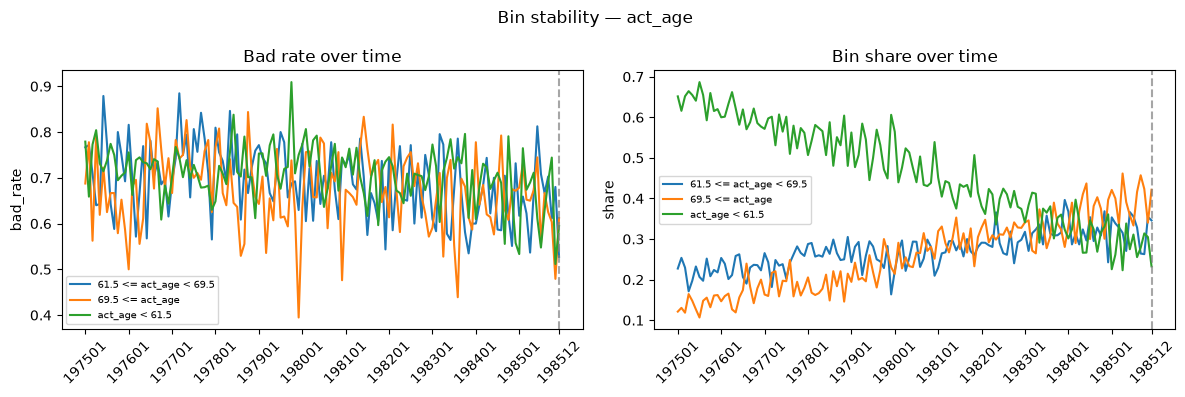

In [37]:
def plot_bin_stability(period_table, feature, train_end_period=None, min_n=None, tick_every=6):
    if period_table.empty:
        return
    min_n = min_n or SCORECARD_PARAMS["min_bin_n_period"]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"Bin stability — {feature}")

    for bin_label, sub in period_table.groupby("bin"):
        sub = sub.sort_values("period")
        if sub["n"].min() < min_n:
            continue
        axes[0].plot(sub["period"], sub["bad_rate"], label=str(bin_label))
        axes[1].plot(sub["period"], sub["share"], label=str(bin_label))

    if train_end_period:
        for ax in axes:
            ax.axvline(train_end_period, color="gray", linestyle="--", alpha=0.7)

    # keep only some periods on x-axis
    periods = sorted(period_table["period"].astype(str).unique())
    xticks = periods[::tick_every] if len(periods) > tick_every else periods
    if periods[-1] not in xticks:
        xticks.append(periods[-1])

    axes[0].set_title("Bad rate over time")
    axes[0].set_ylabel("bad_rate")
    axes[1].set_title("Bin share over time")
    axes[1].set_ylabel("share")

    for ax in axes:
        ax.set_xticks(xticks)
        ax.tick_params(axis="x", rotation=45)
        ax.legend(fontsize=7, loc="best")

    plt.tight_layout()
    plt.show()

# --- checkpoint: plot_bin_stability ---
_cp_plot_feat = _cp_feats[0]
print(f"checkpoint plot_bin_stability ({_cp_plot_feat}):")
plot_bin_stability(
    _cp_period_tables[_cp_plot_feat],
    _cp_plot_feat,
    train_end_period=SCORECARD_PARAMS["train_end_period"],
    tick_every=12,
)

checkpoint plot_br_gaps_over_time (act_age):


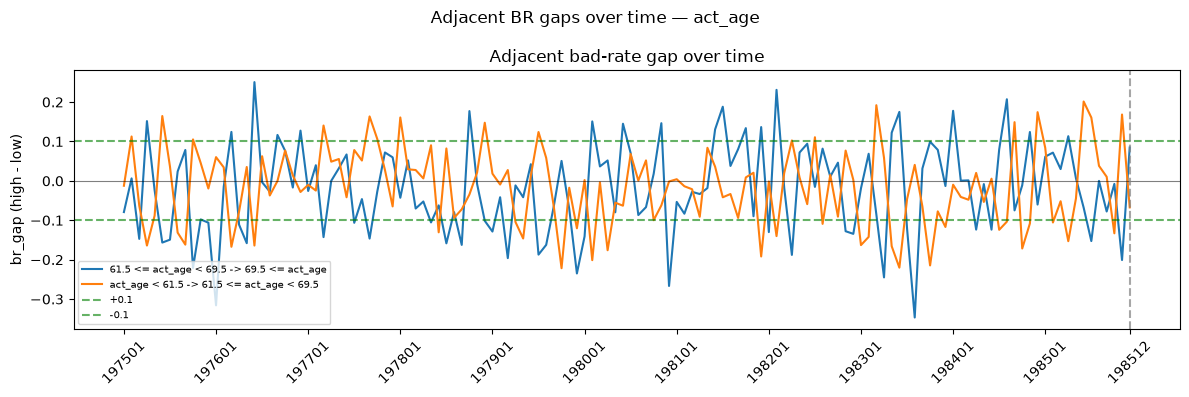

In [38]:
def plot_br_gaps_over_time(period_gaps, feature, train_end_period=None, min_n=None, tick_every=6):
    """Plot adjacent-bin bad-rate gaps over time for eyeballing."""
    if period_gaps is None or period_gaps.empty:
        print("No period gap data to plot")
        return

    min_n = min_n or SCORECARD_PARAMS.get("min_bin_n_period", 10)
    fig, ax = plt.subplots(figsize=(12, 4))
    fig.suptitle(f"Adjacent BR gaps over time — {feature}")

    for pair, sub in period_gaps.groupby("pair"):
        sub = sub.sort_values("period")
        ok = (sub["n_low"] >= min_n) & (sub["n_high"] >= min_n)
        sub = sub.loc[ok]
        if sub.empty:
            continue
        ax.plot(sub["period"], sub["br_gap"], label=str(pair))

    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    min_gap = SCORECARD_PARAMS.get("min_period_br_gap", 0.02)
    ax.axhline(min_gap, color="green", linestyle="--", alpha=0.6, label=f"+{min_gap}")
    ax.axhline(-min_gap, color="green", linestyle="--", alpha=0.6, label=f"-{min_gap}")

    if train_end_period:
        ax.axvline(train_end_period, color="gray", linestyle="--", alpha=0.7)

    periods = sorted(period_gaps["period"].astype(str).unique())
    xticks = periods[::tick_every] if len(periods) > tick_every else periods
    if periods and periods[-1] not in xticks:
        xticks.append(periods[-1])

    ax.set_title("Adjacent bad-rate gap over time")
    ax.set_ylabel("br_gap (high - low)")
    ax.set_xticks(xticks)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=7, loc="best")
    plt.tight_layout()
    plt.show()

# --- checkpoint: plot_br_gaps_over_time ---
print(f"checkpoint plot_br_gaps_over_time ({_cp_feats[0]}):")
plot_br_gaps_over_time(
    _cp_variable_report[_cp_feats[0]]["period_gaps"],
    _cp_feats[0],
    train_end_period=SCORECARD_PARAMS["train_end_period"],
    tick_every=12,
)


checkpoint plot_woe_monotonic_check (act_age): increasing
WOE monotonicity: increasing


,bin,bad_rate_train,woe,woe_step
0,act_age < 61.5,0.712344,-0.021791,NaN
1,61.5 <= act_age < 69.5,0.688193,-0.011425,0.010366
2,69.5 <= act_age,0.670008,0.142729,0.154154


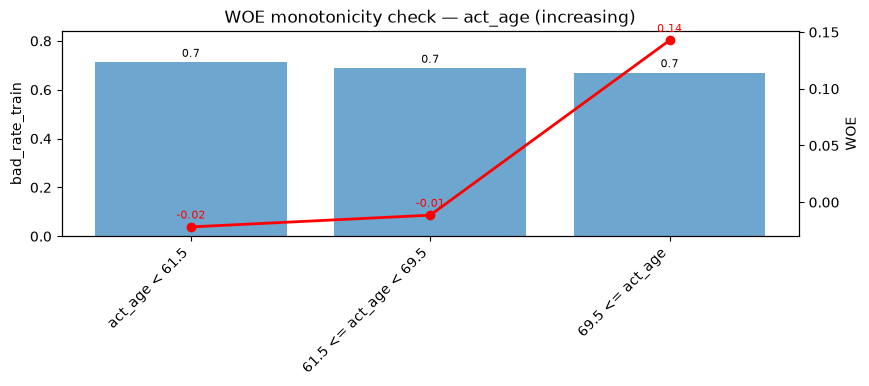

In [39]:
def plot_woe_monotonic_check(woe_ordered, feature, direction=None):
    """Plot WOE in bin-definition order for monotonicity eyeballing."""
    if woe_ordered is None or woe_ordered.empty:
        print("No WOE data to plot")
        return

    direction = direction or "unknown"
    print(f"WOE monotonicity: {direction}")
    display(woe_ordered)

    fig, ax1 = plt.subplots(figsize=(9, 4))
    x = range(len(woe_ordered))
    bars = ax1.bar(x, woe_ordered["bad_rate_train"], alpha=0.65, label="bad_rate_train")
    _ymax = float(woe_ordered["bad_rate_train"].max())
    ax1.set_ylim(0, _ymax * 1.18)
    ax1.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(woe_ordered["bin"].astype(str), rotation=45, ha="right")
    ax1.set_ylabel("bad_rate_train")

    ax2 = ax1.twinx()
    ax2.plot(x, woe_ordered["woe"], color="red", marker="o", linewidth=2, label="WOE")
    for i, y in enumerate(woe_ordered["woe"]):
        ax2.annotate(
            f"{y:.2f}", (i, y), textcoords="offset points", xytext=(0, 6),
            ha="center", fontsize=8, color="red",
        )
    ax2.set_ylabel("WOE")
    plt.title(f"WOE monotonicity check — {feature} ({direction})")
    plt.tight_layout()
    fig.subplots_adjust(top=0.90)
    plt.show()

# --- checkpoint: plot_woe_monotonic_check ---
_cp_woe_ordered, _cp_woe_inc, _cp_woe_dec, _cp_woe_dir = check_woe_monotonicity(
    _cp_big_scorecard, _cp_feats[0], _cp_maps
)
print(f"checkpoint plot_woe_monotonic_check ({_cp_feats[0]}): {_cp_woe_dir}")
plot_woe_monotonic_check(_cp_woe_ordered, _cp_feats[0], _cp_woe_dir)


checkpoint display_variable_report (act_age):
### act_age
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
0,act_age,0.041984,0.088755,1.114027,0.002759,0.24388,0.216543,0.457115,1,0,0,unknown,True,False,False,False,False,True,True,True,False,delta_gini too high (1.114 vs threshold 0.2); ...,1 unstable bin(s): 69.5 <= act_age (bad rate s...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
0,61.5 <= act_age < 69.5,0.357343,0.527273,0.884615,25,5141,False,
1,69.5 <= act_age,0.457115,0.394737,0.851852,16,4888,True,bad rate swing too high
2,act_age < 61.5,0.397463,0.511628,0.909091,29,8903,False,


Static bins (Big_scorecard left block)


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
0,61.5 <= act_age < 69.5,61.5 <= act_age < 69.5,0.688193,0.271551,5141,3538,1603,-0.011425
1,69.5 <= act_age,69.5 <= act_age,0.670008,0.258187,4888,3275,1613,0.142729
2,act_age < 61.5,act_age < 61.5,0.712344,0.470262,8903,6342,2561,-0.021791


WOE monotonicity check
WOE monotonicity: increasing


,bin,bad_rate_train,woe,woe_step
0,act_age < 61.5,0.712344,-0.021791,NaN
1,61.5 <= act_age < 69.5,0.688193,-0.011425,0.010366
2,69.5 <= act_age,0.670008,0.142729,0.154154


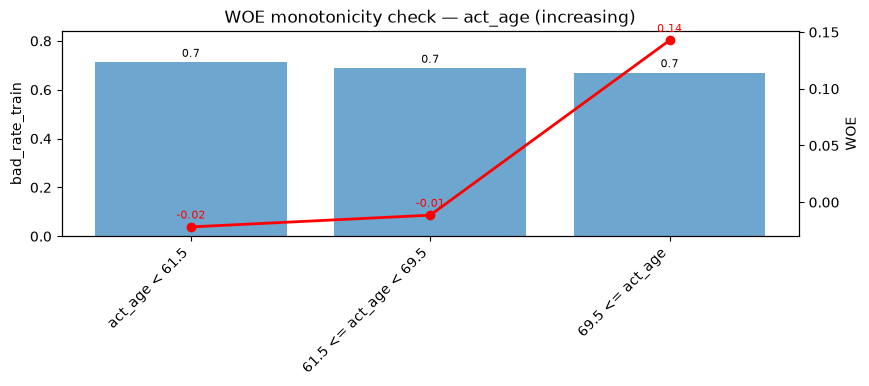

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_age,act_age < 61.5,61.5 <= act_age < 69.5,0.712344,0.688193,-0.024151,0.024151,0.665885,0.643004,-0.022881,0.022881,True,True
1,act_age,61.5 <= act_age < 69.5,69.5 <= act_age,0.688193,0.670008,-0.018185,0.018185,0.643004,0.581579,-0.061425,0.061425,False,True


Adjacent bad-rate gaps over time (head)


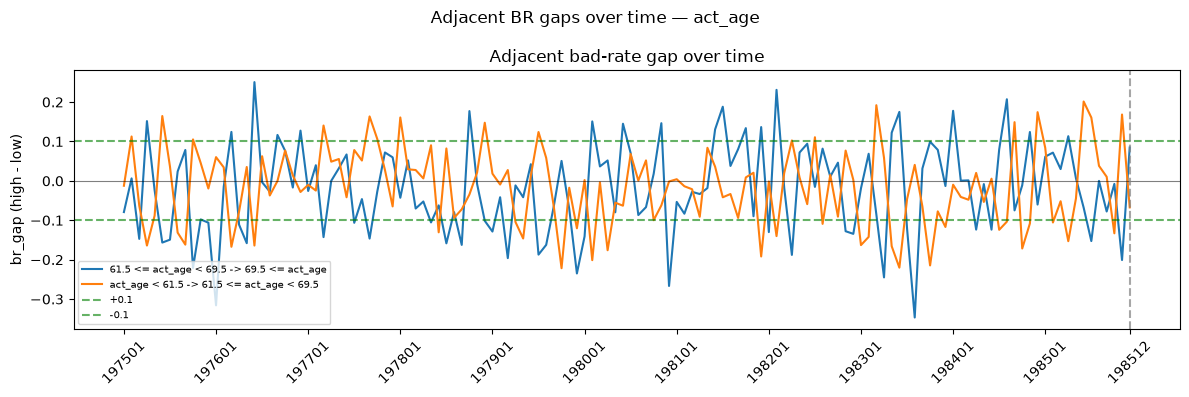

Period × bin (Variable_report right block)


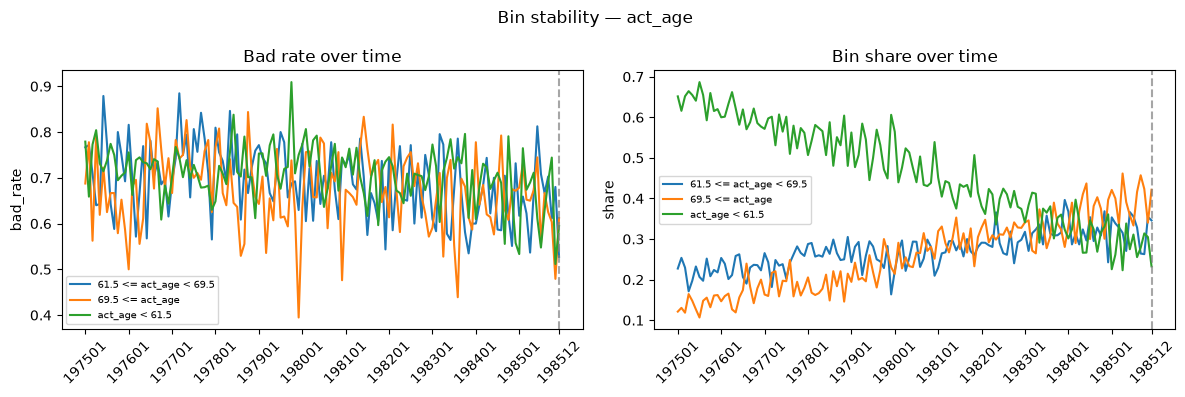

In [40]:
REVIEW_VAR_COLS = [
    "variable", "gini_train", "gini_valid", "delta_gini", "iv", "psi", "psi_tar",
    "max_bad_rate_swing", "n_unstable_bins",
    "n_fail_static_gaps", "n_fail_period_gaps", "woe_direction",
    "pass_gini_train", "pass_delta_gini", "pass_iv", "pass_psi", "pass_psi_tar",
    "pass_static_br_gap", "pass_period_br_gap", "pass_woe_monotonic",
    "safe_to_include", "safety_reason", "stability_reason",
]
REVIEW_BIN_COLS = [
    "bin", "bad_rate_swing", "min_bad_rate", "max_bad_rate",
    "min_n_period", "total_n", "flag_unstable", "flag_reason",
]
REVIEW_GAP_COLS = [
    "pair", "abs_br_gap_train", "abs_br_gap_valid", "n_fail_periods",
    "min_abs_br_gap", "flag_unstable", "flag_reason",
]


def display_variable_report(
    variable_report,
    feature,
    master_review_vars=None,
    master_review_bins=None,
    master_review_gaps=None,
):
    block = variable_report[feature]
    print(f"### {feature}")

    if master_review_vars is not None:
        print("Variable-level prescreen + stability")
        _var_row = master_review_vars.loc[master_review_vars["variable"] == feature, REVIEW_VAR_COLS]
        display(_var_row)

    if master_review_bins is not None:
        print("Bin-level bad-rate swing")
        _bin_rows = master_review_bins.loc[master_review_bins["variable"] == feature, REVIEW_BIN_COLS]
        display(_bin_rows)


    if (
        master_review_gaps is not None
        and "variable" in master_review_gaps.columns
    ):
        _gap_rows = master_review_gaps.loc[master_review_gaps["variable"] == feature]
        _gap_cols = [c for c in REVIEW_GAP_COLS if c in _gap_rows.columns]
        if len(_gap_rows) and _gap_cols:
            print("Adjacent-bin BR gap flags")
            display(_gap_rows[_gap_cols])

    print("Static bins (Big_scorecard left block)")
    display(block["static"])

    woe_ordered = block.get("woe_ordered", pd.DataFrame())
    woe_mono = block.get("woe_monotonic", {})
    if woe_ordered is not None and len(woe_ordered):
        print("WOE monotonicity check")
        plot_woe_monotonic_check(
            woe_ordered,
            feature,
            direction=woe_mono.get("direction", "unknown"),
        )

    static_gaps = block.get("static_gaps", pd.DataFrame())
    if static_gaps is not None and len(static_gaps):
        print("Adjacent bad-rate gaps (static)")
        min_gap = SCORECARD_PARAMS.get("min_static_br_gap", 0.02)
        gaps_view = static_gaps.copy()
        gaps_view["pass_min_gap_train"] = gaps_view["abs_br_gap_train"] >= min_gap
        gaps_view["pass_min_gap_valid"] = gaps_view["abs_br_gap_valid"] >= min_gap
        display(gaps_view)

    period_gaps = block.get("period_gaps", pd.DataFrame())
    if period_gaps is not None and len(period_gaps):
        print("Adjacent bad-rate gaps over time (head)")
        plot_br_gaps_over_time(
            period_gaps,
            feature,
            train_end_period=SCORECARD_PARAMS["train_end_period"],
            tick_every=12,
        )

    print("Period × bin (Variable_report right block)")
    plot_bin_stability(
        block["period"],
        feature,
        train_end_period=SCORECARD_PARAMS["train_end_period"],
        tick_every=12,
    )

# --- checkpoint: display_variable_report ---
_cp_plot_feat = _cp_feats[0]
print(f"checkpoint display_variable_report ({_cp_plot_feat}):")
display_variable_report(
    _cp_variable_report, _cp_plot_feat,
    master_review_vars=_cp_master_vars,
    master_review_bins=_cp_master_bins,
    master_review_gaps=_cp_master_gaps if '_cp_master_gaps' in dir() else None,
)


In [41]:
# §2.1 — Overview (build bins/WOE + master review table)
binning_maps = fit_binning_maps(train_product, cand["all"], SCORECARD_PARAMS["target"], SCORECARD_PARAMS)
_no_split = [
	f for f, spec in binning_maps.items()
	if spec.get("type") == "numeric" and spec.get("no_numeric_split")
]
if _no_split:
	print(
		"WARN auto-binning: no numeric split for",
		_no_split,
		"— likely missing-only signal; tune in §2.3",
	)

artifacts = assign_review_artifacts(
	refresh_review_artifacts(binning_maps, train_product, valid_product, cand, SCORECARD_PARAMS)
)
train_binned = artifacts["train_binned"]
valid_binned = artifacts["valid_binned"]
train_woe = artifacts["train_woe"]
valid_woe = artifacts["valid_woe"]
woe_maps = artifacts["woe_maps"]
iv_table = artifacts["iv_table"]
big_scorecard = artifacts["big_scorecard"]
gini_vars = artifacts["gini_vars"]
review_vars = artifacts["review_vars"]
stability_flags = artifacts["stability_flags"]
static_br_gap_flags = artifacts["static_br_gap_flags"]
period_br_gap_flags = artifacts["period_br_gap_flags"]
woe_flags = artifacts["woe_flags"]
master_review_vars = artifacts["master_review_vars"]
master_review_bins = artifacts["master_review_bins"]
master_review_gaps = artifacts["master_review_gaps"]
vars_selected = artifacts["vars_selected"]

print(f"master_review_vars coverage: {len(master_review_vars)} / {len(cand['all'])} candidates")
# print_artifact_summary(artifacts, binning_maps=binning_maps)

manual_review_batch, needs_manual_review = build_manual_review_batch(master_review_vars, mode="unsafe")
print(f"needs_manual_review: {needs_manual_review}")
print(f"manual_review_batch (top unsafe): {len(manual_review_batch)}")
display(manual_review_batch.head())
print("Next: run §2.2a to pick feature_to_review, then §2.2b for detail review.")


WARN auto-binning: no numeric split for ['app_loan_amount', 'app_n_installments', 'app_installment', 'act_cins_n_loans_act', 'act_cins_maxdue', 'act_cins_min_pninst', 'act_cins_min_lninst', 'act_cins_utl', 'act_cins_dueutl', 'act_cins_n_statB'] — likely missing-only signal; tune in §2.3
master_review_vars coverage: 56 / 56 candidates
needs_manual_review: True
manual_review_batch (top unsafe): 10


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order,n_metric_fails,manual_review_rank
0,act_ccss_dueutl,0.605397,0.604824,0.000946,1.524332,0.014624,0.006338,0.145574,80,True,True,True,True,True,False,1 period BR gap pair(s) unstable,review,,3,0,0.347097,48,,0,1,True,False,decreasing,True,52,1,1
1,act_cins_utl,0.212362,0.181609,0.144815,0.187276,0.013762,0.017607,0.612508,143,True,True,True,True,True,False,1 period BR gap pair(s) unstable,review,,2,0,0.369960,60,,0,1,True,False,decreasing,True,46,1,2
2,act_cins_dueutl,0.212362,0.181609,0.144815,0.187276,0.013762,0.017607,0.612508,55,True,True,True,True,True,False,1 period BR gap pair(s) unstable,review,,2,0,0.369960,60,,0,1,True,False,decreasing,True,47,1,3
3,act_cins_maxdue,0.212362,0.181609,0.144815,0.187276,0.013762,0.017607,0.612508,8,True,True,True,True,True,False,1 period BR gap pair(s) unstable,review,,2,0,0.369960,60,,0,1,True,False,decreasing,True,48,1,4
4,act_cins_min_pninst,0.212362,0.181609,0.144815,0.187276,0.013762,0.017607,0.612508,37,True,True,True,True,True,False,1 period BR gap pair(s) unstable,review,,2,0,0.369960,60,,0,1,True,False,decreasing,True,49,1,5


Next: run §2.2a to pick feature_to_review, then §2.2b for detail review.


### §2.1 notes — how to read review tables
- `safety_reason`: combined explanation (metric fails + stability issues).
- `stability_reason`: bin-level time stability summary (which bins failed and why).
- Metric examples: `delta_gini too high (0.24 vs threshold 0.2)`, `iv too low (0.01 vs threshold 0.02)`.
- Stability examples: `2 unstable bin(s) over time: act_age < 62 (bad rate swing too high ...); 62 <= act_age (too few obs in a period ...)`.
- In `master_review_bins`, use `flag_unstable` + `flag_reason` for bin-by-bin detail.
- BR gap / WOE examples: `1 static BR gap(s) too small; WOE not monotonic (not_monotonic)`.
- In `master_review_gaps`, use pair-level `flag_unstable` + `flag_reason` for adjacent-bin gap detail.


In [90]:
# §2.2a — Pick variable to review
feature_to_review = manual_review_batch["variable"].iloc[0]
print(f"feature_to_review: {feature_to_review!r}")

_edit = extract_bin_edit(binning_maps[feature_to_review])
display_bin_edit_sheet(feature_to_review, _edit)

manual_bin_edits = manual_bin_edits if "manual_bin_edits" in dir() else {}
manual_bin_edits[feature_to_review] = _edit
print("Edit in §2.3a → manual_bin_edits[...] only (cutpoints or groups)")


feature_to_review: 'act_ccss_cc'
'act_ccss_cc': {'type': 'numeric', 'cutpoints': [0.506, 0.637]}  → 3 bin(s)
Edit in §2.3a → manual_bin_edits[...] only (cutpoints or groups)


### act_ccss_cc
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
33,act_ccss_cc,0.29847,0.286693,0.039456,0.336662,0.023532,0.037434,0.431034,1,0,2,decreasing,True,True,True,True,True,True,False,True,False,1 unstable bin(s): 0.506 <= act_ccss_cc < 0.63...,1 unstable bin(s): 0.506 <= act_ccss_cc < 0.63...


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
55,0.506 <= act_ccss_cc < 0.637,0.431034,0.500000,0.931034,24,4664,True,bad rate swing too high
56,0.637 <= act_ccss_cc,0.333333,0.666667,1.000000,26,5354,False,
57,act_ccss_cc < 0.506,0.354730,0.375000,0.729730,40,8914,False,


Adjacent-bin BR gap flags


,pair,abs_br_gap_train,abs_br_gap_valid,n_fail_periods,min_abs_br_gap,flag_unstable,flag_reason
73,act_ccss_cc < 0.506 -> 0.506 <= act_ccss_cc < ...,0.173663,0.209005,NaN,NaN,False,
74,0.506 <= act_ccss_cc < 0.637 -> 0.637 <= act_c...,0.098690,0.080295,NaN,NaN,False,
168,0.506 <= act_ccss_cc < 0.637 -> 0.637 <= act_c...,NaN,NaN,70.0,0.001014,True,"gap too small in 70 period(s) (threshold 0.1, ..."
169,act_ccss_cc < 0.506 -> 0.506 <= act_ccss_cc < ...,NaN,NaN,27.0,0.001634,True,"gap too small in 27 period(s) (threshold 0.1, ..."


Static bins (Big_scorecard left block)


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
123,0.506 <= act_ccss_cc < 0.637,0.506 <= act_ccss_cc < 0.637,0.748714,0.246355,4664,3492,1172,-0.268846
124,0.637 <= act_ccss_cc,0.637 <= act_ccss_cc,0.847404,0.282802,5354,4537,817,-0.891465
125,act_ccss_cc < 0.506,act_ccss_cc < 0.506,0.575050,0.470843,8914,5126,3788,0.520430


WOE monotonicity check
WOE monotonicity: decreasing


,bin,bad_rate_train,woe,woe_step
0,act_ccss_cc < 0.506,0.575050,0.520430,NaN
1,0.506 <= act_ccss_cc < 0.637,0.748714,-0.268846,-0.789275
2,0.637 <= act_ccss_cc,0.847404,-0.891465,-0.622619


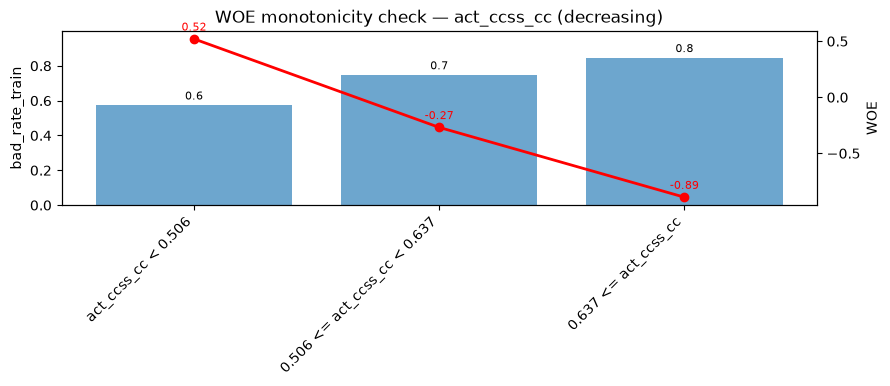

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_ccss_cc,act_ccss_cc < 0.506,0.506 <= act_ccss_cc < 0.637,0.575050,0.748714,0.173663,0.173663,0.468584,0.677590,0.209005,0.209005,True,True
1,act_ccss_cc,0.506 <= act_ccss_cc < 0.637,0.637 <= act_ccss_cc,0.748714,0.847404,0.098690,0.098690,0.677590,0.757885,0.080295,0.080295,True,True


Adjacent bad-rate gaps over time (head)


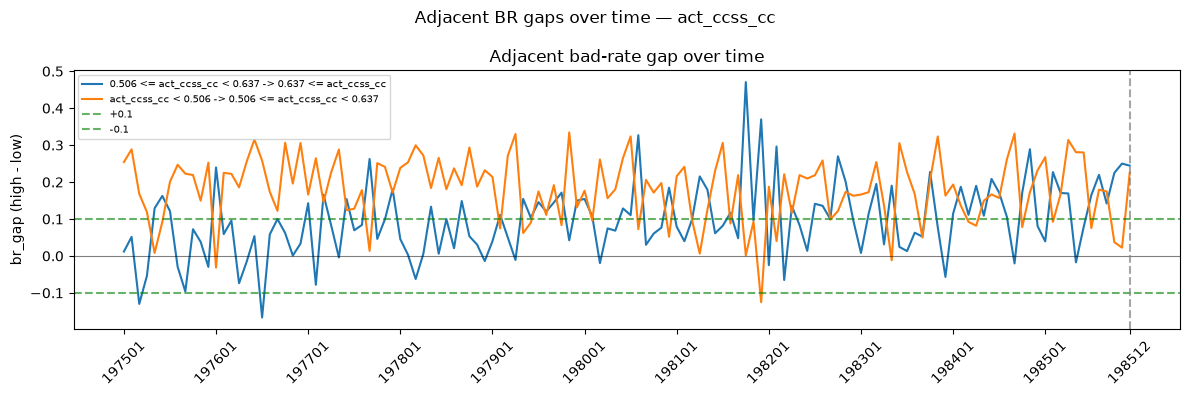

Period × bin (Variable_report right block)


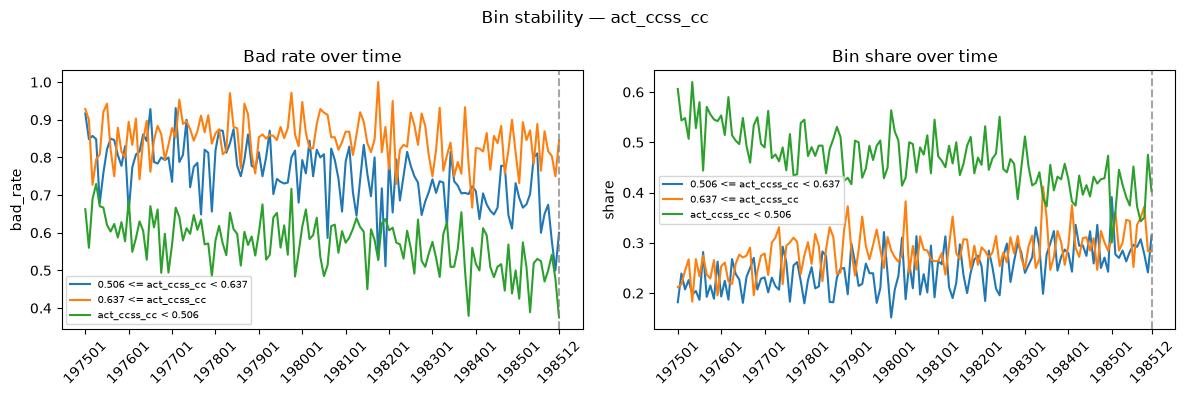

Next: edit §2.3a manual_bin_edits for this feature, then run §2.3b → §2.3b-post.


In [91]:
# §2.2b — Detail review (build + display report for feature_to_review)
target = SCORECARD_PARAMS["target"]
time_col = SCORECARD_PARAMS["time_col"]

period_tables, _ = bin_stability_report(
	train_binned, [feature_to_review], target, time_col, SCORECARD_PARAMS
)
variable_report = build_variable_report(
	train_binned, big_scorecard, [feature_to_review],
	target, time_col, SCORECARD_PARAMS,
	period_tables=period_tables,
	binning_maps=binning_maps,
)
display_variable_report(
	variable_report, feature_to_review,
	master_review_vars=master_review_vars,
	master_review_bins=master_review_bins,
	master_review_gaps=master_review_gaps if "master_review_gaps" in dir() else None,
)
print("Next: edit §2.3a manual_bin_edits for this feature, then run §2.3b → §2.3b-post.")


In [107]:
# §2.3a — Manual bin edits (YOU edit) → auto-compile to manual_binning_overrides
import pprint

# Edit cutpoints (numeric) or groups (nominal) only — no edges/intervals/inf formatting.
manual_bin_edits = {
	# 'act_ccss_dueutl': {'type': 'numeric', 'cutpoints': [0.06]},
	# 'act_call_cc': {'type': 'numeric', 'cutpoints': [2.5]},
	'act_ccss_cc': {'type': 'numeric', 'cutpoints': [0.5]}
}

manual_binning_overrides = build_manual_binning_overrides(
	manual_bin_edits, binning_maps, SCORECARD_PARAMS
)
print(f"Compiled overrides: {sorted(manual_binning_overrides.keys())}")
for _feat, _spec in manual_binning_overrides.items():
	print(f"\n--- {_feat} ---")
	display_bin_edit_sheet(_feat, manual_bin_edits[_feat])
	pprint.pprint(_spec, width=120, sort_dicts=False)


Compiled overrides: ['act_ccss_cc']

--- act_ccss_cc ---
'act_ccss_cc': {'type': 'numeric', 'cutpoints': [0.5]}  → 2 bin(s)
{'type': 'numeric',
 'feature': 'act_ccss_cc',
 'edges': [-inf, 0.5, inf],
 'intervals': ['act_ccss_cc < 0.5', '0.5 <= act_ccss_cc'],
 'missing_label': 'Missing',
 'missing_bin': False,
 'no_numeric_split': False}


In [108]:
# §2.3b — Apply bin overrides + refresh artifacts
manual_binning_overrides = build_manual_binning_overrides(
	manual_bin_edits, binning_maps, SCORECARD_PARAMS
)

for feat, edit in manual_bin_edits.items():
	assert feat in binning_maps, f"{feat} not found in binning_maps"
	spec = manual_binning_overrides[feat]
	assert spec["type"] == edit["type"], f"{feat}: edit/spec type mismatch"
	if spec["type"] == "numeric":
		assert len(spec["edges"]) >= 2, f"{feat}: edges must have at least 2 boundaries"
		assert len(spec["intervals"]) == len(spec["edges"]) - 1, (
			f"{feat}: intervals must be len(edges)-1"
		)
	elif spec["type"] == "nominal":
		assert len(spec["intervals"]) == len(edit["groups"]), (
			f"{feat}: intervals must match number of groups"
		)
		assert set(spec["intervals"]) <= set(spec["category_map"].values()), (
			f"{feat}: every interval must appear in category_map values"
		)
	else:
		raise ValueError(f"{feat}: unknown binning type {spec['type']!r}")
	binning_maps[feat] = spec

print("Applied manual overrides:", sorted(manual_binning_overrides.keys()))

artifacts = assign_review_artifacts(
	refresh_review_artifacts(binning_maps, train_product, valid_product, cand, SCORECARD_PARAMS)
)
train_binned = artifacts["train_binned"]
valid_binned = artifacts["valid_binned"]
train_woe = artifacts["train_woe"]
valid_woe = artifacts["valid_woe"]
woe_maps = artifacts["woe_maps"]
iv_table = artifacts["iv_table"]
big_scorecard = artifacts["big_scorecard"]
gini_vars = artifacts["gini_vars"]
review_vars = artifacts["review_vars"]
stability_flags = artifacts["stability_flags"]
static_br_gap_flags = artifacts["static_br_gap_flags"]
period_br_gap_flags = artifacts["period_br_gap_flags"]
woe_flags = artifacts["woe_flags"]
master_review_vars = artifacts["master_review_vars"]
master_review_bins = artifacts["master_review_bins"]
master_review_gaps = artifacts["master_review_gaps"]
vars_selected = artifacts["vars_selected"]
if "manual_variable_decisions" in dir():
    master_review_vars = apply_manual_variable_decisions(
        master_review_vars, manual_variable_decisions
    )
    vars_selected = select_vars_from_manual_review(master_review_vars)

for _feat in manual_binning_overrides:
	_row = master_review_vars.loc[master_review_vars["variable"] == _feat]
	display(_row)

manual_review_batch, needs_manual_review = build_manual_review_batch(master_review_vars, mode="unsafe")
print(f"needs_manual_review: {needs_manual_review}")
print(f"manual_review_batch (top unsafe): {len(manual_review_batch)}")
display(manual_review_batch.head())
print("Next: run §2.3b-post to re-inspect overridden feature(s), then §2.3c/§2.3d.")


Applied manual overrides: ['act_ccss_cc']


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order
50,act_ccss_cc,0.262571,0.250811,0.044786,0.28249,0.02615,0.040672,0.145574,2806,True,True,True,True,True,False,1 period BR gap pair(s) unstable,review,,2,0,0.343318,53,,0,1,True,False,decreasing,True,51


needs_manual_review: True
manual_review_batch (top unsafe): 10


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,percent_missing,count_unique,pass_gini_train,pass_delta_gini,pass_psi_tar,pass_psi,pass_iv,safe_to_include,safety_reason,manual_decision,manual_note,n_bins,n_unstable_bins,max_bad_rate_swing,max_min_n_period,stability_reason,n_fail_static_gaps,n_fail_period_gaps,pass_static_br_gap,pass_period_br_gap,woe_direction,pass_woe_monotonic,review_plot_order,n_metric_fails,manual_review_rank
0,act_ccss_cc,0.262571,0.250811,0.044786,0.282490,0.026150,0.040672,0.145574,2806,True,True,True,True,True,False,1 period BR gap pair(s) unstable,review,,2,0,0.343318,53,,0,1,True,False,decreasing,True,51,1,1
1,act12_n_arrears,0.536579,0.539052,0.004609,1.158742,0.008899,0.000455,0.000000,12,True,True,True,True,True,False,1 unstable bin(s): 4.5 <= act12_n_arrears < 9....,review,,3,1,0.462049,51,1 unstable bin(s): 4.5 <= act12_n_arrears < 9....,0,2,True,False,decreasing,True,33,1,2
2,act3_n_arrears_days,0.175662,0.192636,0.096628,0.270588,0.000268,0.002468,0.000000,4,True,True,True,True,True,False,1 unstable bin(s): <OTHERS> (bad rate swing to...,review,,3,1,1.000000,97,1 unstable bin(s): <OTHERS> (bad rate swing to...,0,1,True,False,increasing,True,37,1,3
3,act_cins_n_loan,0.214367,0.172362,0.195946,0.198180,0.015972,0.019490,0.000000,5,True,True,True,True,True,False,1 unstable bin(s): <OTHERS> (bad rate swing to...,review,,3,1,1.000000,66,1 unstable bin(s): <OTHERS> (bad rate swing to...,0,1,True,False,decreasing,True,36,1,4
4,app_number_of_children,0.141578,0.113906,0.195452,0.088714,0.021429,0.025276,0.000000,4,True,True,True,True,True,False,2 unstable bin(s): 0.5 <= app_number_of_childr...,review,,3,2,0.508403,63,2 unstable bin(s): 0.5 <= app_number_of_childr...,0,2,True,False,increasing,True,19,1,5


Next: run §2.3b-post to re-inspect overridden feature(s), then §2.3c/§2.3d.


features_to_recheck: ['act_ccss_cc']
### act_ccss_cc
Variable-level prescreen + stability


,variable,gini_train,gini_valid,delta_gini,iv,psi,psi_tar,max_bad_rate_swing,n_unstable_bins,n_fail_static_gaps,n_fail_period_gaps,woe_direction,pass_gini_train,pass_delta_gini,pass_iv,pass_psi,pass_psi_tar,pass_static_br_gap,pass_period_br_gap,pass_woe_monotonic,safe_to_include,safety_reason,stability_reason
50,act_ccss_cc,0.262571,0.250811,0.044786,0.28249,0.02615,0.040672,0.343318,0,0,1,decreasing,True,True,True,True,True,True,False,True,False,1 period BR gap pair(s) unstable,


Bin-level bad-rate swing


,bin,bad_rate_swing,min_bad_rate,max_bad_rate,min_n_period,total_n,flag_unstable,flag_reason
55,0.5 <= act_ccss_cc,0.277455,0.628205,0.905660,53,10264,False,
56,act_ccss_cc < 0.5,0.343318,0.370968,0.714286,40,8668,False,


Static bins (Big_scorecard left block)


,bin,condition,bad_rate_train,share_train,n_train,bads_train,goods_train,woe
123,0.5 <= act_ccss_cc,0.5 <= act_ccss_cc,0.797545,0.542151,10264,8186,2078,-0.548102
124,act_ccss_cc < 0.5,act_ccss_cc < 0.5,0.573258,0.457849,8668,4969,3699,0.527761


WOE monotonicity check
WOE monotonicity: decreasing


,bin,bad_rate_train,woe,woe_step
0,act_ccss_cc < 0.5,0.573258,0.527761,NaN
1,0.5 <= act_ccss_cc,0.797545,-0.548102,-1.075863


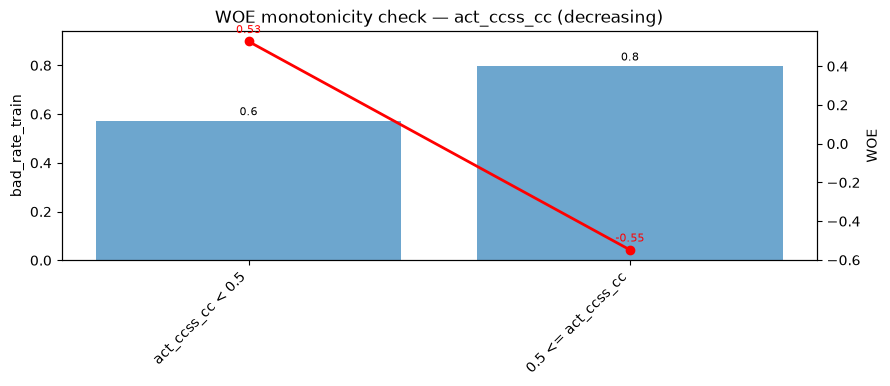

Adjacent bad-rate gaps (static)


,variable,bin_low,bin_high,br_low_train,br_high_train,br_gap_train,abs_br_gap_train,br_low_valid,br_high_valid,br_gap_valid,abs_br_gap_valid,pass_min_gap_train,pass_min_gap_valid
0,act_ccss_cc,act_ccss_cc < 0.5,0.5 <= act_ccss_cc,0.573258,0.797545,0.224287,0.224287,0.464822,0.715865,0.251043,0.251043,True,True


Adjacent bad-rate gaps over time (head)


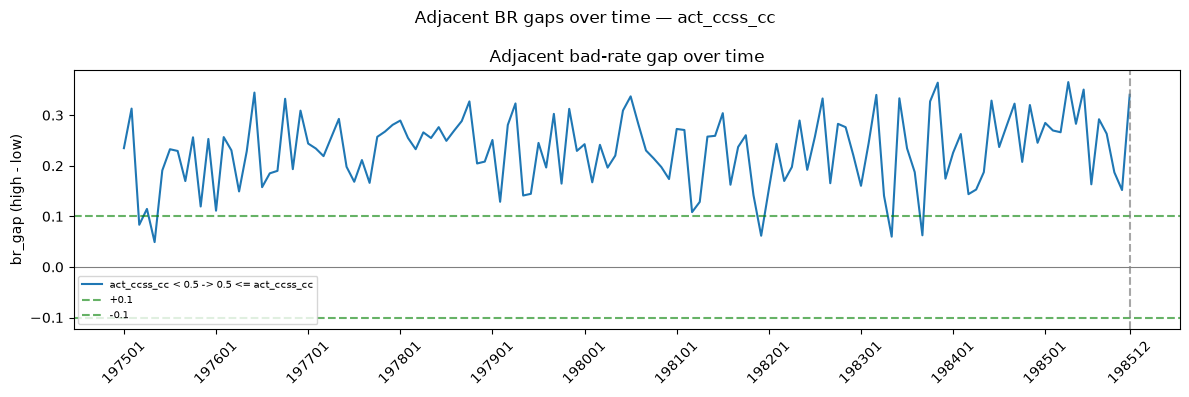

Period × bin (Variable_report right block)


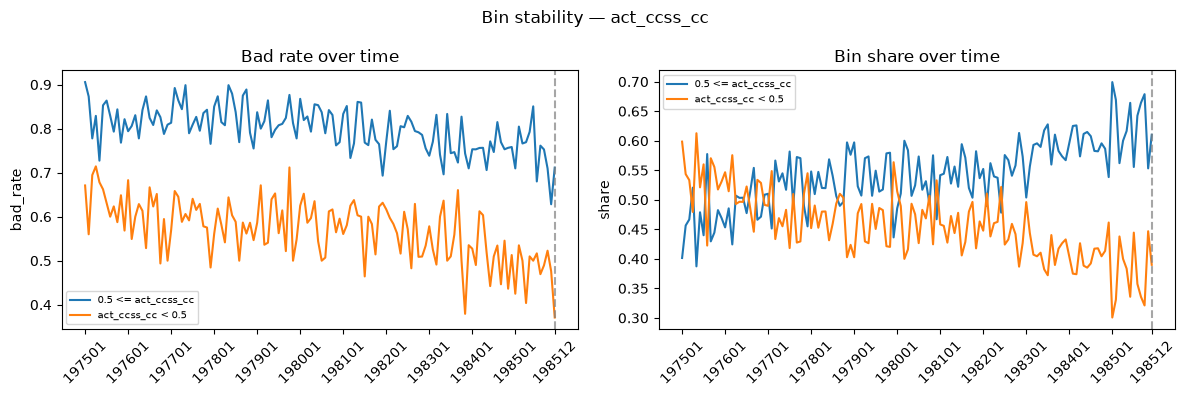

Post-fix review: 'act_ccss_cc'  safe_to_include=False


In [109]:
# §2.3b-post — Re-inspect feature(s) after bin override (re-run after §2.3b)
target = SCORECARD_PARAMS["target"]
time_col = SCORECARD_PARAMS["time_col"]
_features_to_recheck = [feature_to_review] or sorted(manual_binning_overrides.keys())
print(f"features_to_recheck: {_features_to_recheck}")

for _feat in _features_to_recheck:
	period_tables, _ = bin_stability_report(
		train_binned, [_feat], target, time_col, SCORECARD_PARAMS
	)
	_report = build_variable_report(
		train_binned, big_scorecard, [_feat],
		target, time_col, SCORECARD_PARAMS,
		period_tables=period_tables,
		binning_maps=binning_maps,
	)
	display_variable_report(
		_report, _feat,
		master_review_vars=master_review_vars,
		master_review_bins=master_review_bins,
	)
	_safe = master_review_vars.loc[master_review_vars["variable"] == _feat, "safe_to_include"]
	print(f"Post-fix review: {_feat!r}  safe_to_include={bool(_safe.iloc[0]) if len(_safe) else 'n/a'}")


### §2 loop reminder
After `§2.3b-post`, repeat `§2.2a` → `§2.2b` → `§2.3a` → `§2.3b` → `§2.3b-post` until acceptable.
Record keep/drop in `§2.3c`, apply via `§2.3d`.
`§2.3b` refreshes bins/WOE/review tables — do not rerun `§2.1` after overrides.
When done, run `§2.4` once as final gate before §3.


In [ ]:
# §2.3c — Manual variable decisions (dict only; accumulate across loop)
manual_variable_decisions = {
    "act_ccss_dueutl"       :       {"decision": "keep", "note": "combined bins"},
    "act_cins_utl"          :       {"decision": "keep", "note": "Missing = no ins history; no crossing"},
    "act_cins_dueutl"       :       {"decision": "keep", "note": "Missing = no ins history; no crossing"},
    "act_cins_maxdue"       :       {"decision": "keep", "note": "Missing = no ins history; no crossing"},
    "act_cins_min_pninst"   :       {"decision": "keep", "note": "Missing = no ins history; no crossing"},
    "act_cins_min_lninst"   :       {"decision": "keep", "note": "Missing = no ins history; no crossing"},
    "act_cins_n_loans_act"  :       {"decision": "keep", "note": "Missing = no ins history; no crossing"},
    "act_call_cc"           :       {"decision": "keep", "note": "combined bins"},
    "act_ccss_cc"           :       {"decision": "keep", "note": "combined bins"},
}
print(f"manual_variable_decisions keys: {sorted(manual_variable_decisions.keys())}")


manual_variable_decisions keys: ['act_call_cc', 'act_ccss_dueutl', 'act_cins_dueutl', 'act_cins_maxdue', 'act_cins_min_lninst', 'act_cins_min_pninst', 'act_cins_n_loans_act', 'act_cins_utl']


In [89]:
# §2.3d — Apply manual variable decisions + rebuild review queue
for var, cfg in manual_variable_decisions.items():
    mask = master_review_vars["variable"].eq(var)
    if not mask.any():
        print(f"WARN: {var} not in master_review_vars")
        continue
    master_review_vars.loc[mask, "manual_decision"] = cfg["decision"]
    master_review_vars.loc[mask, "manual_note"] = cfg.get("note", "")

vars_selected = select_vars_from_manual_review(master_review_vars)
print(f"vars_selected (manual_decision='keep'): {len(vars_selected)}")
print(vars_selected)

manual_review_batch, needs_manual_review = build_manual_review_batch(master_review_vars, mode="pending")
print(f"needs_manual_review: {needs_manual_review}")
print(f"manual_review_batch (pending review): {len(manual_review_batch)}")
display(manual_review_batch[["variable", "manual_decision", "manual_note", "n_metric_fails"]].head(10))
if len(manual_review_batch):
    print(f"Next §2.2a: feature_to_review = {manual_review_batch['variable'].iloc[0]!r}")
else:
    print("manual_review_batch empty — run §2.4 final gate.")


vars_selected (manual_decision='keep'): 8
['act_cins_min_pninst', 'act_cins_utl', 'act_cins_dueutl', 'act_cins_n_loans_act', 'act_cins_maxdue', 'act_cins_min_lninst', 'act_call_cc', 'act_ccss_dueutl']
needs_manual_review: True
manual_review_batch (pending review): 10


,variable,manual_decision,manual_note,n_metric_fails
0,act_ccss_cc,review,,1
1,act12_n_arrears,review,,1
2,act3_n_arrears_days,review,,1
3,act_cins_n_loan,review,,1
4,app_number_of_children,review,,1
5,act_cins_min_seniority,review,,1
6,act_ccss_n_loans_act,review,,2
7,act_cc,review,,2
8,act_ccss_min_lninst,review,,2
9,act_ccss_min_pninst,review,,2


Next §2.2a: feature_to_review = 'act_ccss_cc'


In [ ]:
# §2.4 — Final gate before §3 (run once after loop is complete)
vars_selected_pre_time = select_vars_from_manual_review(master_review_vars)
print(f"vars_selected_pre_time (manual_decision='keep'): {len(vars_selected_pre_time)} of {len(master_review_vars)}")

# optional time gate
def build_feature_gini_time_summary(df_woe, features, target, time_col, min_rows=50):
    rows = []
    for feat in features:
        woe_col = f"{feat}_WOE"
        if woe_col not in df_woe.columns:
            continue
        for period, sub in df_woe.groupby(time_col):
            n = len(sub)
            if n < min_rows or sub[target].nunique() < 2:
                continue
            gini_val = compute_gini(sub[target], sub[woe_col])
            rows.append({"variable": feat, "period": str(period), "n": n, "gini": gini_val})

    per_period = pd.DataFrame(rows)
    if per_period.empty:
        return per_period, pd.DataFrame(columns=["variable", "n_periods", "gini_first", "gini_last", "gini_delta", "gini_slope"])

    summary_rows = []
    for var, sub in per_period.sort_values("period").groupby("variable"):
        vals = sub["gini"].to_numpy(dtype=float)
        x = np.arange(len(vals), dtype=float)
        slope = float(np.polyfit(x, vals, 1)[0]) if len(vals) >= 2 else np.nan
        summary_rows.append({
            "variable": var,
            "n_periods": int(len(vals)),
            "gini_first": float(vals[0]),
            "gini_last": float(vals[-1]),
            "gini_delta": float(vals[-1] - vals[0]),
            "gini_slope": slope,
        })

    return per_period, pd.DataFrame(summary_rows).sort_values(["gini_slope", "gini_delta"], ascending=False)

time_gate_cfg = SCORECARD_PARAMS.get("time_gate", {})
time_gate_cfg.setdefault("min_periods", SCORECARD_PARAMS.get("min_periods_for_stability", 6))
time_gate_cfg.setdefault("gini_slope_min", 0.0)
time_gate_cfg.setdefault("gini_delta_min", -0.02)

gini_time_vars, gini_time_summary = build_feature_gini_time_summary(
    valid_woe, vars_selected_pre_time, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"]
)

if gini_time_summary.empty:
    stable_time_vars = set(vars_selected_pre_time)
else:
    stable_time_vars = set(gini_time_summary.loc[
        (gini_time_summary["n_periods"] >= time_gate_cfg["min_periods"])
        & (gini_time_summary["gini_slope"] >= time_gate_cfg["gini_slope_min"])
        & (gini_time_summary["gini_delta"] >= time_gate_cfg["gini_delta_min"]),
        "variable",
    ])

vars_selected = [v for v in vars_selected_pre_time if v in stable_time_vars]
vars_rejected_time = [v for v in vars_selected_pre_time if v not in stable_time_vars]

thin_bins = big_scorecard.loc[
    (big_scorecard["variable"].isin(vars_selected))
    & (big_scorecard["share_train"] < SCORECARD_PARAMS["minimum_share_int"])
]

print(f"vars_selected_after_time_gate: {len(vars_selected)}")
print(f"§2 final check — PRODUCT={PRODUCT} vars_selected={len(vars_selected)} thin_bins={len(thin_bins)}")

if len(vars_selected) >= 10 and thin_bins.empty:
    print("§2 PASS — proceed to §3")
else:
    print("§2 NOT PASS — rerun §2.1 and continue manual review loop")
    if len(thin_bins):
        display(thin_bins[["variable", "bin", "share_train"]].head(20))
    if vars_rejected_time:
        display(gini_time_summary[gini_time_summary["variable"].isin(vars_rejected_time)].sort_values("gini_slope"))

_(Legacy §2 cells below were merged into §2.1–§2.4. Keep scrolling to §3.)_


## §3 — Model fit (after §2.4 final gate passes)

Staged workflow — run cells in order; re-run from any checkpoint when tuning.

- **§3.1** Slice product data + candidate WOE columns
- **§3.2** RFE shortlist (top `number_vars`)
- **§3.3** Build `Model_list` (full shortlist + all `number_features` combos)
- **§3.4** Diagnose near-misses
- **§3.5** Filter `subModel_list`
- **§3.5b** Compute + review BR stability (`var_summary` + plots) — `subModel_list` variables only
- **§3.6** Pick winner (auto or manual)
- **§3.7** Fit final logit + effects
- **§3.8** Assemble `model_package` for §4+


In [ ]:
# §3.1 — Slice product data + candidate WOE columns
vars_for_modeling = vars_selected

target = SCORECARD_PARAMS["target"]
train_subset = slice_product(train_woe, PRODUCT)
valid_subset = slice_product(valid_woe, PRODUCT)
candidate_woe = [f"{f}_WOE" for f in vars_for_modeling if f"{f}_WOE" in train_woe.columns]
print(f"PRODUCT={PRODUCT}  train={len(train_subset)}  valid={len(valid_subset)}  candidate_woe={len(candidate_woe)}")


In [ ]:
# §3.2 — RFE shortlist
number_vars = SCORECARD_PARAMS["selection"]["number_vars"]
rfe_model = LogisticRegression(solver="lbfgs", max_iter=1000)
rfe = RFE(estimator=rfe_model, n_features_to_select=1, step=1)
rfe.fit(train_subset[candidate_woe], train_subset[target])
rfe_ranking = pd.Series(rfe.ranking_, index=candidate_woe)
shortlisted = rfe_ranking[rfe_ranking <= number_vars].sort_values().index.tolist()
display(rfe_ranking.sort_values().head(15))
print("shortlisted:", shortlisted)


In [ ]:
def _assess_combo(feature_set):
    x_train = sm.add_constant(train_subset[feature_set], has_constant="add")
    y_train = train_subset[target]
    model = sm.Logit(y_train, x_train).fit(disp=0)
    feature_cols = [c for c in model.params.index if c != "const"]
    x_valid = sm.add_constant(valid_subset[feature_cols], has_constant="add")
    pred_train = model.predict(x_train)
    pred_valid = model.predict(x_valid)
    gini_train = compute_gini(train_subset[target], pred_train)
    gini_valid = compute_gini(valid_subset[target], pred_valid)
    pvalues = model.pvalues.drop(labels=["const"], errors="ignore")
    max_pvalue = float(pvalues.max()) if len(pvalues) else 0.0
    vif_series = check_vif(train_subset[feature_cols])
    max_vif = float(vif_series.max()) if len(vif_series) else 1.0
    betas = model.params.drop(labels=["const"], errors="ignore")
    nnegative_betas = int((betas < 0).sum())
    return {
        "Variables": ",".join(feature_set),
        "n_features": len(feature_set),
        "nnegative_betas": nnegative_betas,
        "max_pvalue": max_pvalue,
        "max_vif": max_vif,
        "gini_train": gini_train,
        "gini_valid": gini_valid,
        "ar_diff": abs(gini_train - gini_valid),
    }

# --- checkpoint: _assess_combo ---
_probe = _assess_combo(shortlisted[: min(3, len(shortlisted))])
print("checkpoint _assess_combo:", _probe)


In [ ]:
# §3.3 — Build Model_list
number_features = SCORECARD_PARAMS["selection"]["number_features"]
rows = []
fit_failures = 0

try:
    rows.append(_assess_combo(shortlisted))
except Exception as exc:
    fit_failures += 1
    print("full shortlist fit failed:", exc)

for combo in combinations(shortlisted, number_features):
    try:
        rows.append(_assess_combo(list(combo)))
    except Exception:
        fit_failures += 1
        continue

Model_list = pd.DataFrame(rows)
print("Model_list shape:", Model_list.shape, "  fit_failures:", fit_failures)
display(Model_list.head(10))


In [ ]:
# §3.4 — Diagnose near-misses before filtering
sel = SCORECARD_PARAMS["selection"]
print("Model_list rows:", len(Model_list))
display(Model_list[["nnegative_betas", "max_pvalue", "max_vif", "gini_valid"]].describe())

print("pass sign:", (Model_list["nnegative_betas"] > 0).sum())
print("pass pvalue:", (Model_list["max_pvalue"] <= sel["pvalue_max"]).sum())
print("pass vif:", (Model_list["max_vif"] <= sel["vif_max"]).sum())
print(
    "pass all three:",
    (
        (Model_list["nnegative_betas"] > 0)
        & (Model_list["max_pvalue"] <= sel["pvalue_max"])
        & (Model_list["max_vif"] <= sel["vif_max"])
    ).sum(),
)

near = Model_list.sort_values(["gini_valid"], ascending=[False])
display(near.head(5))


In [ ]:
# §3.5 — Filter subModel_list
sel = SCORECARD_PARAMS["selection"]
sort_metric = sel.get("sort_metric", "gini_valid")

subModel_list = Model_list[
    (Model_list["nnegative_betas"] > 0)
    & (Model_list["max_pvalue"] <= sel["pvalue_max"])
    & (Model_list["max_vif"] <= sel["vif_max"])
].sort_values(sort_metric, ascending=False).reset_index(drop=True)

print("subModel_list shape:", subModel_list.shape)
display(subModel_list.head())
if subModel_list.empty:
    print("No combo passes filters — inspect near-misses in §3.4, tune §2/params, or use MANUAL_OVERRIDE in §3.6")


In [ ]:
# §3.5b — BR stability review (subModel_list variables only)
stability_flags = pd.DataFrame()
variable_report = {}

if subModel_list.empty:
    print("subModel_list is empty — skip BR review until a passing combo exists or MANUAL_OVERRIDE is set in §3.6")
else:
    submodel_vars = sorted({
        (f[:-4] if f.endswith("_WOE") else f)
        for vars_str in subModel_list["Variables"]
        for f in vars_str.split(",")
    })
    print(f"subModel_list variables to review: {len(submodel_vars)}")

    period_tables, stability_flags = bin_stability_report(
        train_binned, submodel_vars, SCORECARD_PARAMS["target"],
        SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    )
    variable_report = build_variable_report(
        train_binned, big_scorecard, submodel_vars,
        SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
        period_tables=period_tables,
        binning_maps=binning_maps,
    )

    var_summary = (
        stability_flags.groupby("variable", as_index=False)
        .agg(
            n_bins=("bin", "count"),
            n_unstable=("flag_unstable", "sum"),
            max_swing=("bad_rate_swing", "max"),
            worst_bin=("bad_rate_swing", lambda s: stability_flags.loc[s.idxmax(), "bin"]),
            min_n_period=("min_n_period", "min"),
        )
        .sort_values(["n_unstable", "max_swing"], ascending=[False, False])
    )
    display(var_summary)

    problems = (
        stability_flags.query("flag_unstable")
        .sort_values("bad_rate_swing", ascending=False)
        [["variable", "bin", "bad_rate_swing", "min_n_period", "total_n", "flag_reason"]]
    )
    display(problems)

    max_plots = SCORECARD_PARAMS.get("max_plots")
    feats_to_plot = submodel_vars if max_plots is None else submodel_vars[:max_plots]
    for feat in feats_to_plot:
        display_variable_report(
            variable_report, feat,
            master_review_vars=master_review_vars if 'master_review_vars' in dir() else None,
            master_review_bins=master_review_bins if 'master_review_bins' in dir() else None,
            master_review_gaps=master_review_gaps if 'master_review_gaps' in dir() else None,
        )


In [ ]:
# §3.6 — Pick winner (auto or manual)
WINNER_ROW = 0
# MANUAL_OVERRIDE = ["act9_n_arrears_WOE", "act_ccss_maxdue_WOE", ...]
MANUAL_OVERRIDE = []

if "MANUAL_OVERRIDE" in dir() and MANUAL_OVERRIDE:
    selected_woe = list(MANUAL_OVERRIDE)
elif not subModel_list.empty:
    selected_woe = subModel_list.loc[WINNER_ROW, "Variables"].split(",")
else:
    selected_woe = []
    print("No auto winner — set MANUAL_OVERRIDE or relax filters in §3.5")

selected_features = [f[:-4] if f.endswith("_WOE") else f for f in selected_woe]
print("selected_woe:", selected_woe)
print("selected_features:", selected_features)

if selected_features and (
    stability_flags.empty
    or not set(selected_features).issubset(set(stability_flags["variable"].unique()))
):
    period_tables, stability_flags = bin_stability_report(
        train_binned, selected_features, SCORECARD_PARAMS["target"],
        SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
    )
    variable_report = build_variable_report(
        train_binned, big_scorecard, selected_features,
        SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"], SCORECARD_PARAMS,
        period_tables=period_tables,
        binning_maps=binning_maps,
    )
    print(f"BR stability computed for {len(selected_features)} selected features")


In [ ]:
# §3.7 — Fit final logit + effects
if not selected_woe:
    print("SKIP §3.7 — no features selected; complete §3.6 with MANUAL_OVERRIDE or relax §3.5 filters")
else:
    x_train = sm.add_constant(train_subset[selected_woe], has_constant="add")
    final_model = sm.Logit(train_subset[target], x_train).fit(disp=0)

    feature_cols = [c for c in final_model.params.index if c != "const"]
    x_valid = sm.add_constant(valid_subset[feature_cols], has_constant="add")
    pred_train = final_model.predict(x_train)
    pred_valid = final_model.predict(x_valid)
    gini_train = compute_gini(train_subset[target], pred_train)
    gini_valid = compute_gini(valid_subset[target], pred_valid)
    pvalues = final_model.pvalues.drop(labels=["const"], errors="ignore")
    max_pvalue = float(pvalues.max()) if len(pvalues) else 0.0
    vif_series = check_vif(train_subset[feature_cols])
    max_vif = float(vif_series.max()) if len(vif_series) else 1.0
    betas = final_model.params.drop(labels=["const"], errors="ignore")
    nnegative_betas = int((betas < 0).sum())

    metrics = {
        "gini_train": gini_train,
        "gini_valid": gini_valid,
        "ar_diff": abs(gini_train - gini_valid),
        "max_pvalue": max_pvalue,
        "max_vif": max_vif,
        "nnegative_betas": nnegative_betas,
        "n_features": len(feature_cols),
        "pvalues": pvalues.to_dict(),
        "vif": vif_series.to_dict(),
    }

    print("metrics:", metrics)

    effects = pd.DataFrame([
        {
            "feature": feat,
            "beta": final_model.params[feat],
            "pvalue": final_model.pvalues[feat],
            "vif": vif_series.get(feat, np.nan),
        }
        for feat in feature_cols
    ]).assign(abs_beta=lambda d: d["beta"].abs()).sort_values("abs_beta", ascending=False).drop(columns=["abs_beta"])
    display(effects)


In [ ]:
# §3.8 — Assemble model_package for §4+
if not selected_woe:
    print("SKIP §3.8 — no model_package (§3.7 skipped)")
else:
    woe_tables = {}
    for woe_col in selected_woe:
        raw_feat = woe_col[: -len("_WOE")]
        grp_key = f"{raw_feat}_GRP"
        if grp_key in woe_maps:
            woe_tables[woe_col] = woe_maps[grp_key]

    model_package = {
        "product": PRODUCT,
        "features": selected_woe,
        "model": final_model,
        "metrics": metrics,
        "effects": effects,
        "train_subset": train_subset,
        "valid_subset": valid_subset,
        "woe_tables": woe_tables,
        "id_col": SCORECARD_PARAMS.get("id_col", "aid"),
        "rfe_ranking": rfe_ranking,
        "Model_list": Model_list,
        "subModel_list": subModel_list,
    }

    from math import comb
    shortlisted_len = int((rfe_ranking <= SCORECARD_PARAMS["selection"]["number_vars"]).sum())
    nf = SCORECARD_PARAMS["selection"]["number_features"]
    expected_combo_rows = comb(shortlisted_len, nf) + 1 if shortlisted_len >= nf else 0

    print("Model_list rows:", len(Model_list), "expected from shortlist:", expected_combo_rows)
    print("contains agr/ags in candidates:", any(f.startswith(("agr", "ags")) for f in cand["all"]))
    print("act9_n_arrears in candidates:", "act9_n_arrears" in cand["all"])
    print("notebook selected vars:", selected_features)
    print("model_package ready for §4")


## §4 — Scorecard points & calibration

In [ ]:
def scale_scorecard(model_package, factor, offset):
	model = model_package["model"]
	features = model_package["features"]
	intercept = model.params.get("const", 0.0)
	base_points = offset - factor * intercept
	rows = []
	for feat in features:
		beta = model.params[feat]
		woe_table = model_package.get("woe_tables", {}).get(feat)
		if woe_table is None:
			rows.append({"feature": feat, "bin": "<ALL>", "woe": np.nan, "points": np.nan})
			continue
		for _, row in woe_table.iterrows():
			rows.append({
				"feature": feat,
				"bin": row["bin"],
				"woe": row["woe"],
				"points": -beta * row["woe"] * factor,
			})
	points_table = pd.DataFrame(rows)
	points_table.attrs["base_points"] = base_points
	points_table.attrs["intercept"] = intercept
	points_table.attrs["factor"] = factor
	points_table.attrs["offset"] = offset
	return points_table

# --- checkpoint: scale_scorecard ---
_pt = scale_scorecard(model_package, SCORECARD_PARAMS["factor"], SCORECARD_PARAMS["offset"])
print(f"checkpoint scale_scorecard: {len(_pt)} rows base={_pt.attrs.get('base_points', 0):.1f}")

In [ ]:
def score_applicants(df_woe, model_package, points_table=None):
	features = model_package["features"]
	id_col = model_package.get("id_col", "aid")
	out = pd.DataFrame({id_col: df_woe[id_col].values})
	if points_table is not None:
		base_points = points_table.attrs.get("base_points", 0.0)
		total = pd.Series(base_points, index=df_woe.index, dtype=float)
		for feat in features:
			raw_feat = feat[: -len("_WOE")]
			grp_col = f"{raw_feat}_GRP"
			feat_points_map = (
				points_table[points_table["feature"] == feat]
				.set_index("bin")["points"]
				.to_dict()
			)
			contrib = df_woe[grp_col].map(feat_points_map).fillna(0.0)
			out[f"{feat}_points"] = contrib.values
			total = total + contrib
		out["score"] = total.values
	else:
		model = model_package["model"]
		x = df_woe[features].copy()
		x.insert(0, "const", 1.0)
		out["score"] = x.values @ model.params[["const"] + features].values
	return out.rename(columns={id_col: "aid"}) if id_col != "aid" else out

# --- checkpoint: score_applicants ---
_sc = score_applicants(valid_woe.head(20), model_package, _pt)
print("checkpoint score_applicants:")
display(_sc.head())


In [ ]:
def calibrate_pd(scores_df, target="default12"):
	y = scores_df[target].values
	score = scores_df["score"].values
	x = sm.add_constant(score)
	calib_model = sm.Logit(y, x).fit(disp=0)
	param_index = calib_model.params.index.tolist()
	a = float(calib_model.params["const"]) if "const" in param_index else float(calib_model.params.iloc[0])
	slope_cols = [c for c in param_index if c != "const"]
	b = float(calib_model.params[slope_cols[0]]) if slope_cols else 0.0
	pd_calibrated = calib_model.predict(x)
	return {
		"params": {"intercept": a, "coef": b, "target": target, "score_col": "score"},
		"diagnostics": {
			"auc_before": float(roc_auc_score(y, score)),
			"auc_after": float(roc_auc_score(y, pd_calibrated)),
			"brier_before": float(brier_score_loss(y, (score - score.min()) / (score.max() - score.min() + 1e-12))),
			"brier_after": float(brier_score_loss(y, pd_calibrated)),
			"mean_pd_predicted": float(pd_calibrated.mean()),
			"mean_pd_actual": float(y.mean()),
		},
	}

# --- checkpoint: calibrate_pd ---
_cal = calibrate_pd(valid_scored, target=SCORECARD_PARAMS["target"])
print("checkpoint calibrate_pd:")

In [ ]:
def variable_importance_from_points(points_table):
	scale = (
		points_table.groupby("feature")["points"]
		.agg(min_points="min", max_points="max")
		.reset_index()
	)
	scale["range"] = scale["max_points"] - scale["min_points"]
	total_range = scale["range"].sum()
	scale["importance_pct"] = scale["range"] / total_range if total_range else 0.0
	return scale.sort_values("importance_pct", ascending=False)

# --- checkpoint: variable_importance_from_points ---
_imp = variable_importance_from_points(points_table)
print("checkpoint variable_importance_from_points:")

In [ ]:
def plot_calibration_curve(scores_df, target, n_deciles=10):
	work = scores_df[[target, "score"]].dropna().copy()
	work["decile"] = pd.qcut(work["score"], n_deciles, duplicates="drop")
	cal = work.groupby("decile", observed=False).agg(
		n=("score", "count"),
		mean_score=("score", "mean"),
		bad_rate=(target, "mean"),
	).reset_index()
	fig, ax = plt.subplots(figsize=(6, 4))
	ax.plot(cal["mean_score"], cal["bad_rate"])
	ax.set_xlabel("mean score (decile)")
	ax.set_ylabel("actual bad rate")
	ax.set_title("Calibration curve")
	plt.tight_layout()
	plt.show()
	return cal

# --- checkpoint: plot_calibration_curve ---
print("checkpoint plot_calibration_curve:")
_cal_tbl = plot_calibration_curve(valid_scored, SCORECARD_PARAMS["target"])

In [ ]:
if "model_package" not in dir():
    print("SKIP §4 — set MANUAL_OVERRIDE in §3.6 or fix subModel_list first")
else:
    points_table = scale_scorecard(
        model_package, SCORECARD_PARAMS["factor"], SCORECARD_PARAMS["offset"]
    )
    display(points_table.head(20))

    importance = variable_importance_from_points(points_table)
    display(importance)
    importance.plot.barh(x="feature", y="importance_pct", legend=False, figsize=(8, 5))
    plt.xlabel("importance_pct")
    plt.tight_layout()
    plt.show()

    valid_scored = score_applicants(valid_woe, model_package, points_table)
    valid_scored = valid_scored.merge(
        valid_product[[SCORECARD_PARAMS["id_col"], SCORECARD_PARAMS["target"]]].rename(
            columns={SCORECARD_PARAMS["id_col"]: "aid"}
        ),
        on="aid",
    )
    calibration = calibrate_pd(valid_scored, target=SCORECARD_PARAMS["target"])
    print("calibration params:", calibration["params"])

    cal_table = plot_calibration_curve(valid_scored, SCORECARD_PARAMS["target"])
    display(cal_table)


## §5 — Model stability (Gini over time)

In [ ]:
def gini_over_time(scored_df, target, time_col="period", score_col="score", min_n=30):
	rows = []
	for period, sub in scored_df.groupby(time_col):
		if len(sub) < min_n:
			continue
		g = compute_gini(sub[target], sub[score_col])
		rows.append({
			"period": period,
			"n": len(sub),
			"bad_rate": sub[target].mean(),
			"gini": g,
		})
	return pd.DataFrame(rows).sort_values("period")

# --- checkpoint: gini_over_time ---
_gt = gini_over_time(scored_with_period, SCORECARD_PARAMS["target"], SCORECARD_PARAMS["time_col"])
print(f"checkpoint gini_over_time: {len(_gt)} periods")

In [ ]:
def plot_gini_over_time(gini_by_period, overall_gini=None):
	if gini_by_period.empty:
		return
	fig, ax = plt.subplots(figsize=(10, 4))
	ax.plot(gini_by_period["period"], gini_by_period["gini"])
	median_g = gini_by_period["gini"].median()
	ax.axhline(median_g, color="gray", linestyle="--", label=f"median {median_g:.2%}")
	if overall_gini is not None:
		ax.axhline(overall_gini, color="green", linestyle=":", label=f"overall valid {overall_gini:.2%}")
	ax.set_title("Gini over time")
	ax.set_ylabel("Gini")
	ax.tick_params(axis="x", rotation=45)
	ax.legend()
	plt.tight_layout()
	plt.show()
	flagged = gini_by_period[gini_by_period["gini"] < median_g - 0.10]
	if len(flagged):
		print("Warning: periods with Gini >10pp below median:")
		display(flagged)

# --- checkpoint: plot_gini_over_time ---
print("checkpoint plot_gini_over_time:")
plot_gini_over_time(gini_time, overall_gini=model_package["metrics"]["gini_valid"])


In [ ]:
if "valid_scored" not in dir():
    print("SKIP §5 — complete §4 first")
else:
    scored_with_period = valid_scored.merge(
        valid_product[[SCORECARD_PARAMS["id_col"], SCORECARD_PARAMS["time_col"]]].rename(
            columns={SCORECARD_PARAMS["id_col"]: "aid"}
        ),
        on="aid",
    )
    gini_time = gini_over_time(
        scored_with_period,
        SCORECARD_PARAMS["target"],
        SCORECARD_PARAMS["time_col"],
    )
    display(gini_time)
    plot_gini_over_time(gini_time, overall_gini=model_package["metrics"]["gini_valid"])


## §6 — Save artifacts

In [ ]:
def build_model_report(model_package, points_table, gini_time, calibration, cal_table, gini_vars):
	m = model_package["metrics"]
	main = pd.DataFrame({
		"Measure": [
			"gini_train", "gini_valid", "ar_diff", "max_vif",
			"max_pvalue", "n_features", "nnegative_betas",
		],
		"Value": [
			m["gini_train"], m["gini_valid"], m["ar_diff"], m["max_vif"],
			m["max_pvalue"], m["n_features"], m["nnegative_betas"],
		],
	})
	effects = model_package.get("effects")
	if effects is None:
		feature_cols = model_package["features"]
		vif_series = check_vif(model_package["train_subset"][feature_cols])
		effects = pd.DataFrame([
			{"feature": feat, "beta": model_package["model"].params[feat],
			 "pvalue": model_package["model"].pvalues[feat],
			 "vif": vif_series.get(feat, np.nan)}
			for feat in feature_cols
		])
	importance = variable_importance_from_points(points_table)
	scorecard = points_table.copy()
	scorecard["points_round"] = scorecard["points"].round(0)
	cal_df = pd.DataFrame([calibration["params"]])
	cal_df = pd.concat([cal_df, cal_table], ignore_index=True)
	final_vars = [f[: -len("_WOE")] for f in model_package["features"]]
	gini_final = gini_vars[gini_vars["variable"].isin(final_vars)]
	return {
		"Main_measures": main,
		"Effects": effects,
		"Gini_over_time": gini_time,
		"Scorecard": scorecard,
		"Variable importance": importance,
		"Calibration": cal_df,
		"Gini_vars_final": gini_final,
	}

# --- checkpoint: build_model_report ---
_mr = build_model_report(model_package, points_table, gini_time, calibration, cal_table, gini_vars)
print(f"checkpoint build_model_report: sheets={list(_mr.keys())}")

In [ ]:
def display_model_report(model_report):
	for sheet_name, df in model_report.items():
		print(f"## {sheet_name}")
		display(df)
		if sheet_name == "Gini_over_time":
			plot_gini_over_time(df)
		elif sheet_name == "Variable importance":
			df.plot.barh(x="feature", y="importance_pct", legend=False, figsize=(8, 4))
			plt.tight_layout()
			plt.show()

# --- checkpoint: display_model_report ---
print("checkpoint display_model_report:")
display_model_report(model_report)

In [ ]:
def save_product_artifacts(
	product, out_dir, big_scorecard, gini_vars, stability_flags, gini_time,
	model_package, points_table, screen_report, woe_maps, calibration,
):
	out = Path(out_dir)
	out.mkdir(parents=True, exist_ok=True)
	big_scorecard.to_parquet(out / f"big_scorecard_{product}.parquet", index=False)
	gini_vars.to_parquet(out / f"gini_vars_{product}.parquet", index=False)
	stability_flags.to_parquet(out / f"bin_stability_flags_{product}.parquet", index=False)
	gini_time.to_parquet(out / f"gini_by_period_{product}.parquet", index=False)
	points_table.to_parquet(out / f"points_table_{product}.parquet", index=False)
	screen_report.to_parquet(out / f"feature_screen_report_{product}.parquet", index=False)
	with (out / f"pd_{product}.pkl").open("wb") as fh:
		pickle.dump(model_package, fh)
	woe_path = out / "woe_maps.pkl"
	existing = {}
	if woe_path.exists():
		with woe_path.open("rb") as fh:
			existing = pickle.load(fh)
	existing[product] = woe_maps
	with woe_path.open("wb") as fh:
		pickle.dump(existing, fh)
	cal_path = out / "calibration_params.json"
	cal_existing = {}
	if cal_path.exists():
		with cal_path.open(encoding="utf-8") as fh:
			cal_existing = json.load(fh)
	cal_existing[product] = calibration["params"]
	with cal_path.open("w", encoding="utf-8") as fh:
		json.dump(cal_existing, fh, indent=2)

# --- checkpoint: save_product_artifacts ---
_out = Path("../data/06_models/_checkpoint_test")
save_product_artifacts(
    PRODUCT, _out, big_scorecard, gini_vars, stability_flags, gini_time,
    model_package, points_table, screen_report, woe_maps, calibration,
)
print(f"checkpoint save_product_artifacts: wrote to {_out}")

In [ ]:
if "model_package" not in dir():
    print("SKIP §6 — complete §3–§5 first")
else:
    model_report = build_model_report(
        model_package, points_table, gini_time, calibration, cal_table, gini_vars
    )
    display_model_report(model_report)

    save_product_artifacts(
        PRODUCT,
        "../data/06_models",
        big_scorecard,
        gini_vars,
        stability_flags,
        gini_time,
        model_package,
        points_table,
        screen_report,
        woe_maps,
        calibration,
    )

    gini_valid = model_package["metrics"]["gini_valid"]
    print(f"PD {PRODUCT}: {len(model_package['features'])} features, valid Gini {gini_valid:.1%}")
    print("Saved parquet/pkl for", PRODUCT)
    print("When ins is done, set PRODUCT='css' and re-run §2–§6")


In [ ]:
# §6b — Final report reprint
if "model_report" in dir():
    print("Final model report (reprint):")
    display_model_report(model_report)
else:
    print("SKIP §6b — model_report not available yet")


### Optional: full pipeline regression (skips §2 prescreen gate)

In [ ]:

# Optional regression pipeline — SKIPS §2 prescreen gate; use only after manual tuning.
# results = run_full_scorecard_pipeline(
#     "../data/04_feature/abt_app.parquet",
#     "../data/04_feature/decisions.parquet",
#     SCORECARD_PARAMS,
#     output_dir="../data/06_models",
# )
